In [1]:
import matplotlib
#matplotlib.use("Agg") 
import csv, glob, os, sys, time, h5py
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator
from copy import deepcopy
from scipy.spatial import cKDTree
from src.library import *
import matplotlib as mpl
import warnings
import numpy as np
import pandas as pd

mpl.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{mathrsfs}'

MARKERS = ['v', 'o', 'x']
COLORS = [
    "#8E2BAF",  # Deep Purple     — original
    "#148A02",  # Forest Green    — original
    "#C42B8E",  # Magenta Rose    — analogous to purple, warm bridge
    "#AF2B2B",  # Crimson         — bold warm anchor
    "#D4820A",  # Amber           — energetic warm accent
    "#8AAF0A",  # Chartreuse      — yellow-green, bridges to green
    "#0A8A5E",  # Emerald Teal    — cool-green bridge
    "#0A5EAF",  # Royal Blue      — cool counterweight
]
DPI        = 150
ALPHA      = 0.1
SIZE       = 8
FONTSIZE   = 16
GRID_ALPHA = 0.5

In [2]:
def red_to_den(factor: np.array, numb: np.array, criteria = 0.125): # vectorize

    # total number of values of factor array
    total = factor.shape[0]
    #n_ref = np.logspace(np.log10(numb.min()), np.log10(numb.max()), total)

    log_numb = np.log10(numb)          # shape (M,)  — compute ONCE outside loop
    # log space list of `total` values between the min and max of density
    n_ref = 10 ** np.arange(log_numb.min(), log_numb.max() + criteria, criteria)
    log_n_ref   = np.log10(n_ref)           # shape (N,)
    #n_ref = 10 ** np.arange(log_numb.min(), log_numb.max() + criteria, criteria)

    # mask with boolean array, matching the condition log10(n_g(p)/n_{ref}) < 1/8
    #print(log_numb.shape, log_n_ref.shape)
     # <- this creates a matrix such that each row, can be collapse to a mean, median and percentile
    mask = np.abs(log_numb[np.newaxis, :] - log_n_ref[:, np.newaxis]) < (criteria)
    #print(mask)
    #print(mask.shape)
    # broadcast mask to factor[np.newaxis, :] or np.nan
    meet_condition = np.where(mask, factor[np.newaxis, :], np.nan)

    import warnings

    with warnings.catch_warnings(): 
        # following error messages are not relevant, they just point to a empty slice
        warnings.filterwarnings("ignore", message="Mean of empty slice") 
        warnings.filterwarnings("ignore", message="All-NaN slice encountered")

        # mean function that ignores nan values
        mean_vec = np.nanmean(meet_condition, axis=1)
        median_vec = np.nanmedian(meet_condition, axis=1)
        twofive_vec = np.nanquantile(meet_condition, 0.25, axis=1)
        ten_vec = np.nanquantile(meet_condition, 0.1, axis=1)
        five_vec = np.nanquantile(meet_condition, 0.05, axis=1)
        
        sample_size = mask.sum(axis=1).astype(int)
    
    return n_ref, mean_vec, median_vec, twofive_vec, ten_vec, five_vec, sample_size


def red_to_den_keep_spacing(factor: np.array, numb: np.array, n_ref = None, criteria = 1/8): # vectorize

    # total number of values of factor array
    total = factor.shape[0]
    #n_ref = np.logspace(np.log10(numb.min()), np.log10(numb.max()), total)

    log_numb = np.log10(numb)          # shape (M,)  — compute ONCE outside loop
    # log space list of `total` values between the min and max of density

    if n_ref is None:
        n_ref = 10 ** np.arange(log_numb.min(), log_numb.max() + criteria, criteria)

    log_n_ref   = np.log10(n_ref)           # shape (N,)        
    
    # I want to get fraction of all 
    #which_below_unity = np.logical_and(factor < 1.0, factor > 0.0) # for original
    #log_n_ref_below_unity   = log_n_ref[which_below_unity]
    #factor_below_unity      = factor[which_below_unity]

    # mask with boolean array, matching the condition log10(n_g(p)/n_{ref}) < 1/8
    #print(log_numb.shape, log_n_ref.shape)
     # <- this creates a matrix such that each row, can be collapse to a mean, median and percentile
    mask = np.abs(log_numb[np.newaxis, :] - log_n_ref[:, np.newaxis]) < (criteria)
    #print(mask)
    #print(mask.shape)
    # broadcast mask to factor[np.newaxis, :] or np.nan
    meet_condition = np.where(mask, factor[np.newaxis, :], np.nan)

    import warnings

    with warnings.catch_warnings(): 
        # following error messages are not relevant, they just point to a empty slice
        warnings.filterwarnings("ignore", message="Mean of empty slice") 
        warnings.filterwarnings("ignore", message="All-NaN slice encountered")

        # mean function that ignores nan values
        mean_vec = np.nanmean(meet_condition, axis=1)
        median_vec = np.nanmedian(meet_condition, axis=1)
        twofive_vec = np.nanquantile(meet_condition, 0.25, axis=1)
        ten_vec = np.nanquantile(meet_condition, 0.1, axis=1)
        five_vec = np.nanquantile(meet_condition, 0.05, axis=1)
        
        sample_size = mask.sum(axis=1).astype(int)
    
    return n_ref, mean_vec, median_vec, twofive_vec, ten_vec, five_vec, sample_size

In [3]:
import pickle 

with open('./util/cloud_matches.pkl', 'rb') as f:
    data_cloud_pairs = pickle.load(f)

for ith_cloud in data_cloud_pairs:
    print("Cloud ", ith_cloud)
    print(data_cloud_pairs[ith_cloud][0].keys())
    print("ideal ", data_cloud_pairs[ith_cloud][0][["snap", "Peak_Density"]][data_cloud_pairs[ith_cloud][0]["snap"] == 0]['Peak_Density'].iloc[0])
    #print("ideal ", np.log10(data_cloud_pairs[ith_cloud][0]["Peak_Density"].iloc[0]))
    #print("ambip ", np.log10(data_cloud_pairs[ith_cloud][1]["Peak_Density"].iloc[0]))
    break

def get_peak_density_at(cloud, case, snap=None, time=None):
    # cloud => 0 or 1
    # case  => "ideal" or "amb"
    # snap  => 0 - 495
    import pickle 

    with open('./util/cloud_matches.pkl', 'rb') as f:
        data_cloud_pairs = pickle.load(f)

    if case == "ideal":
        case = 0
    else:
        case = 1
    df = data_cloud_pairs[cloud][case]


    if time is not None:
        mask = np.isclose(df["time_value"], time, rtol=0, atol=1e-12) 
        match = df[mask]
        # Number rounded at the smallest precision possible
        # 4.5520477294921875   ← 17 significant digits, ends in ...921875
        # 4.552047729492188    ← 16 significant digits, ends in ...492188
        if match.empty:
            diffs = (df['time_value'] - time).abs()
            raise ValueError(
                f"No time match for cloud={cloud}, case={case}, time={time}.\n"
                f"Closest available: {df['time_value'].iloc[diffs.argmin()]} "
                f"(diff={diffs.min():.7e})"
            )

        matched_time = match['time_value'].iloc[0]
        diff = abs(matched_time - time)
        if diff > 0:
            print(f"[approx match] requested={time}, matched={matched_time}, diff={diff:.3e}")

        return np.log10(match['Peak_Density'].iloc[0])

    if (snap is None) and (time is None):
        raise ValueError
    if (snap is None):
        return np.log10(data_cloud_pairs[cloud][case][["time_value", "Peak_Density"]][data_cloud_pairs[cloud][case]["time_value"] == time]['Peak_Density'].iloc[0])
    if (time is None):
        return np.log10(data_cloud_pairs[cloud][case][["snap", "Peak_Density"]][data_cloud_pairs[cloud][case]["snap"] == snap]['Peak_Density'].iloc[0])
    
    
#data_cloud_pairs[cloud][case][["snap", "Peak_Density"]][data_cloud_pairs[cloud][case]["snap"] == snap]['Peak_Density'].iloc[0]

#print(get_peak_density_at(cloud=0, case="ideal", snap = 495))
#print(get_peak_density_at(cloud=0, case="amb", snap = 495))
#print(get_peak_density_at(cloud=0, case="ideal", snap = 0))
#print(get_peak_density_at(cloud=0, case="amb", snap = 0))

print(4.5520477294921875, get_peak_density_at(cloud=0, case="ideal", time = 4.5520477294921875))

Cloud  0
Index(['snap', 'cloud', 'time_value', 'c_coord_X', 'c_coord_Y', 'c_coord_Z',
       'Peak_Density'],
      dtype='object')
ideal  2465.4052574983207
[approx match] requested=4.5520477294921875, matched=4.552047729492188, diff=8.882e-16
4.5520477294921875 13.531928039641532


In [53]:
def imporfromfile(file, identifier):

    df = pd.read_pickle(file)
    df.index.name = 'snapshot'
    df.index = df.index.astype(str)
    df = df.sort_index()
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_colwidth', None)
    #print(df)
    try:
        t     = df["time"].to_numpy()
        #print("Non-Empty:", file.split("/")[-1])        
    except:
        print("Empty:", file.split("/")[-1])
        return None
    _ = np.argsort(t)
    t     = df["time"].to_numpy()[_]

    x    = df["x_input"].to_numpy()[_]
    n_s    = df["n_rs"].to_numpy()[_]
    B_s    = df["B_rs"].to_numpy()[_]

    surf  = df["surv_fraction"].to_numpy()[_]
    r_u    = df["r_u"].to_numpy()[_]
    r_l    = df["r_l"].to_numpy()[_]
    oscilation_mask  = df["cells_oscilation_mask"].to_numpy()[_]
    never_ending_mask= df["never_ending_mask"].to_numpy()[_]
    eval_reduction_mask= df["eval_reduction_mask"].to_numpy()[_]

    ndivvolume = df["norm_divvolume"].to_numpy()[_]
    ndivN = df["norm_divn"].to_numpy()[_]
    ndivfield = df["norm_divfield"].to_numpy()[_]
    ndivb = df["norm_divb"].to_numpy()[_]
    Npath    = df["n_path"].to_numpy()[_]
    Nlos0    = df["n_los0"].to_numpy()[_]
    Nlos1    = df["n_los1"].to_numpy()[_]
    Snaps    = df["snapshot"].to_numpy()[_].astype(int)
    radius = []
    for ris in x:
        if ris.shape[0] == 0:
            continue
        radius += [np.max(np.linalg.norm(ris, axis=1))]

    if identifier == '2i0' or identifier == '2a0':
        radius = 0.1
    
    #print(oscilation_mask[0].shape, np.sum(oscilation_mask[0]))
    #print(eval_reduction_mask[0].shape)
    #print(never_ending_mask[0].shape)
        

    return {
        "index": Snaps,
        "id": identifier,
        "rloc": radius,
        "m_osci":    oscilation_mask, # oscilates True if oscilates
        "m_nev":     never_ending_mask, # survivors True if doesnt unviable
        "m_eval":     eval_reduction_mask, # oscilates True if oscilates
        "t":     t,
        "x":     x,
        "ru":     r_u,
        "rl":     r_l,
        "ns":     n_s,
        "Bs":     B_s,
        "ndivb":  ndivb,
        "ndivn": ndivN,
        "ndivv":  ndivvolume,
        "ndivf": ndivfield,
        "surf":  surf
    }

In [20]:
#files = list(sorted(glob.glob(f'/home/leni/magnetic_pockets/m-c-stats/lines/*w*.pkl')))
files = list(sorted(glob.glob(f'/home/leni/magnetic_pockets/m-c-stats/series/*_dense/*dense.pkl')))
# excluding weighted and multiple clouds
for file in files:
    print(file)


/home/leni/magnetic_pockets/m-c-stats/series\a0_dense\data_2a0_dense.pkl
/home/leni/magnetic_pockets/m-c-stats/series\i0_dense\data_2i0_dense.pkl


In [54]:
if files:    
    config = {}
    for file in files:

        if "tmp" in file:
            continue

        #print(file)


        ID = file.split('.')[-2][-10:]

        #os.makedirs(f"./series/{ID}", exist_ok=True)
        something = imporfromfile(file, ID)
        if something is None:
            continue

        config[f'data{ID}'] = something
        print(f'data{ID}')
    globals().update(config) # This injects every key as a variable in your script


dense_data = [data_2i0_dense, data_2a0_dense]


data_2a0_dense
data_2i0_dense


[0.125      0.25       0.375      0.4875     0.575      0.65
 0.775      0.8625     0.9625     1.0875     1.1625     1.2875
 1.4        1.525      1.64375    1.70625    1.78125    1.9
 2.0125     2.1375     2.2625     2.3875     2.5125     2.6375
 2.7625     2.8875     3.0125     3.1375     3.2625     3.375
 3.5        3.625      3.75       3.875      4.         4.125
 4.25       4.375      4.5        4.5453125  4.54980469 4.55097656
 4.5515625  4.5517334  4.55179443 4.5519043  4.55196533 4.55201721
 4.55204773 4.55206299] [ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360
 370 380 390 400 410 420 430 440 450 460 470 480 490 495]
(30005, 3)


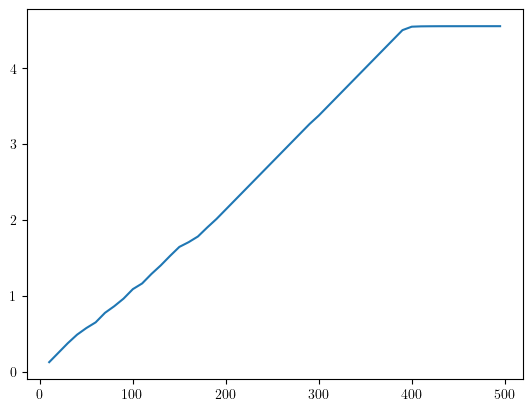

[0.125      0.25       0.375      0.5        0.625      0.75
 0.875      1.         1.125      1.25       1.375      1.5
 1.5875     1.7125     1.8375     1.9625     2.0875     2.2125
 2.3375     2.4875     2.725      2.95       3.2        3.45
 3.7        3.95       4.2        4.28671875 4.29013672 4.29035034
 4.29039917 4.29041748 4.29042587 4.29043312 4.29043694 4.29044075
 4.29044456 4.29044838 4.29045219 4.29045601 4.29045982 4.29046364
 4.29046745 4.29047127 4.29047508 4.2904789  4.29048271 4.29048653
 4.29049034 4.29049225] [ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360
 370 380 390 400 410 420 430 440 450 460 470 480 490 495]
(30005, 3)


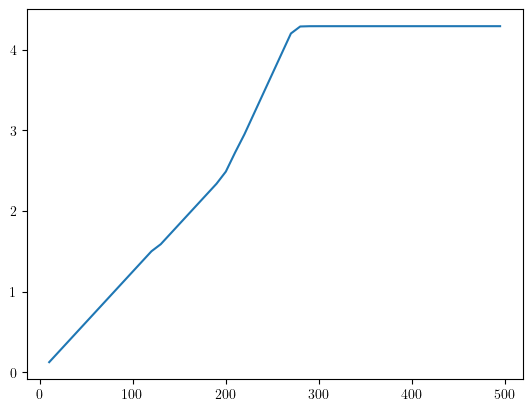

In [55]:
""" Index versus Density """

tindex = -1

for i, data in enumerate(dense_data): 

    fig, ax = plt.subplots()

    ylabel = r'$\mathscr{R}$ [adimensional]'

    #_id     =  data["id"]
    _idx    =  data["index"]
    _tim    =  data["t"]

    print(_tim, _idx)

    n_val = data["ns"][tindex]
    print(data["x"][tindex].shape)

    ax.plot(_idx, _tim)
    plt.show()
    plt.close(fig)
    

(30005, 3)


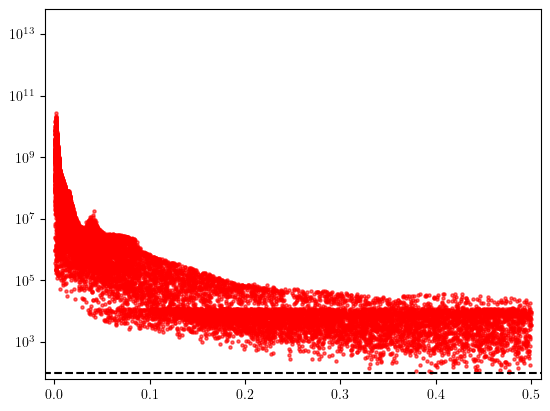

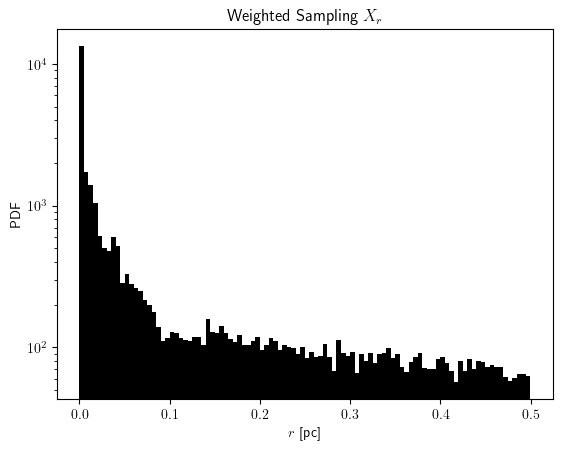

(30005, 3)


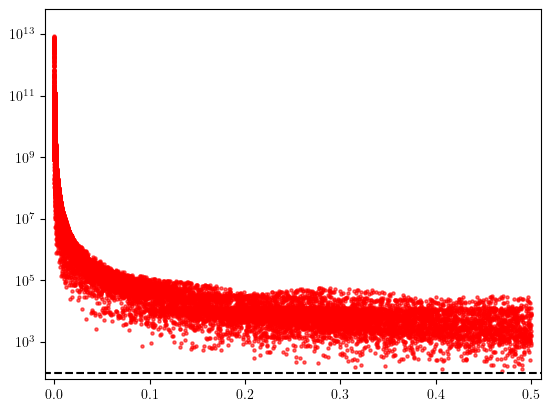

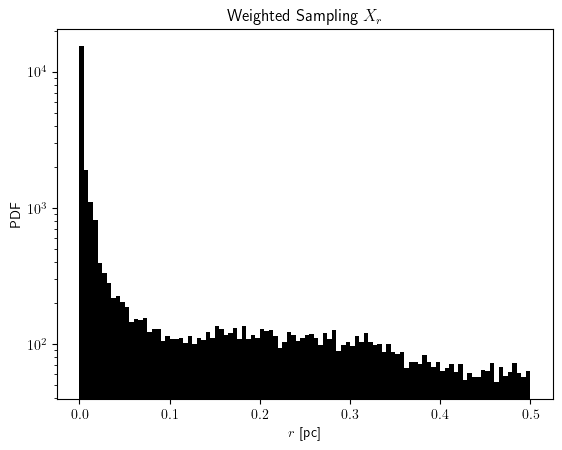

In [56]:
""" Radius versus Density """

tindex = -1

for i, data in enumerate(dense_data): 

    fig, ax = plt.subplots()

    ylabel = r'$\mathscr{R}$ [adimensional]'

    _id     =  data["id"]

    _l_ = data["ru"][tindex] != 0.0 #rt_val < 1
    rt_val = data["ru"][tindex][_l_]
    n_val = data["ns"][tindex][_l_]
    print(data["x"][tindex].shape)
    rad = np.linalg.norm(data["x"][tindex], axis=1)

    ax.scatter(rad, n_val, s = 5, color = 'r', alpha= 0.6)
    ax.hlines(100, -1, 2, linestyle='--', color="black")
    ax.set_yscale("log")
    ax.set_xlim(-0.01, 0.51)
    ax.set_ylim(10**1.8, 10**13.8)
    plt.show()
    plt.close(fig)
    

    fig, ax = plt.subplots()
    #ax.hist(np.log10(Density[cells][maskA]), bins = 80, color = "black")
    ax.hist(rad, bins = 100, color = "black")
    #ax.plot(np.log10(Density[cells][maskA]), bins = 80, color = "black")
    #ax.hist(Density[cells][maskM], bins = 80, color = "black")
    #ax.vlines(100, -0.01, rl*1.01, linestyle='--', color="black")
    #ax.set_xlim(1, 14)
    ax.set_yscale("log")
    ax.set_ylabel(r"PDF")
    ax.set_xlabel(r"$r$ [pc]")
    ax.set_title(rf"Weighted Sampling $X_r$")
    #plt.savefig("./HistogramDensityAbove10e2.png", dpi = 150)
    plt.show()
    plt.close(fig)

[approx match] requested=4.5520477294921875, matched=4.552047729492188, diff=8.882e-16
[approx match] requested=4.5520172119140625, matched=4.552017211914063, diff=8.882e-16
[approx match] requested=1.9000000000000001, matched=1.9, diff=2.220e-16
[approx match] requested=1.5250000000000001, matched=1.525, diff=2.220e-16
[approx match] requested=1.4000000000000001, matched=1.4, diff=2.220e-16
[approx match] requested=1.0875000000000001, matched=1.0875, diff=2.220e-16
[approx match] requested=0.48750000000000004, matched=0.4875, diff=5.551e-17
[approx match] requested=4.2904712677001955, matched=4.290471267700196, diff=8.882e-16
[approx match] requested=4.2904407501220705, matched=4.290440750122071, diff=8.882e-16
[approx match] requested=4.2903991699218755, matched=4.290399169921876, diff=8.882e-16
[approx match] requested=1.9625000000000001, matched=1.9625, diff=2.220e-16
[approx match] requested=1.8375000000000001, matched=1.8375, diff=2.220e-16
[approx match] requested=1.712500000000

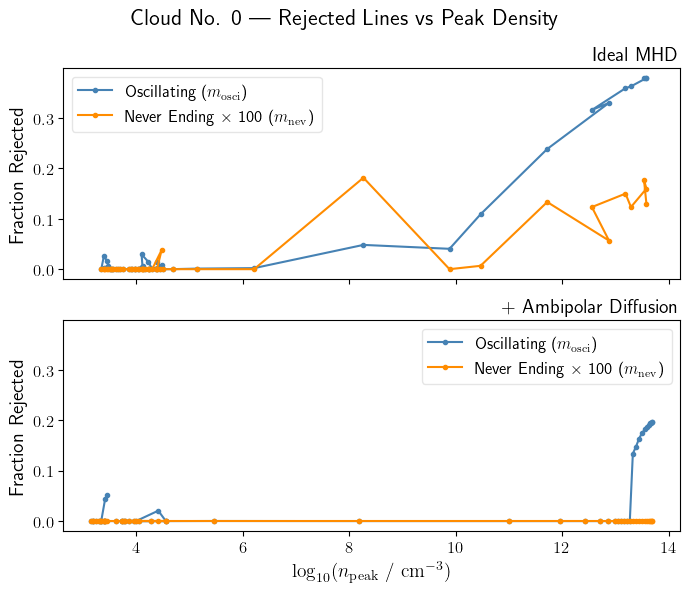

In [57]:
""" Fraction of Rejected as function of density"""

mpl.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{mathrsfs}'

row_titles = [r'Ideal MHD', r'+ Ambipolar Diffusion']
cases      = ["ideal", "amb"]
colors     = ["steelblue", "darkorange", "seagreen"]
labels     = [r"Oscillating ($m_{\rm osci}$)",
              r"Evaluated ($m_{\rm eval}$)",
              r"Never Ending $\times$ 100 ($m_{\rm nev}$)"]

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)
fig.suptitle(r"Cloud No. 0 — Rejected Lines vs Peak Density", fontsize=FONTSIZE)

for ix, data in enumerate(dense_data):
    ax   = axes[ix]
    case = cases[ix]

    peaks  = np.array([get_peak_density_at(cloud=0, case=case, time=t_i)
                       for t_i in data["t"][::-1]])
    m_osci = np.array([np.nansum(f_i)/f_i.shape[0] for f_i in data["m_osci"][::-1]])
    m_nev  = np.array([100*np.nansum(~f_i)/f_i.shape[0] for f_i in data["m_nev"][::-1]])
    sizes = np.array([f_i.shape[0]/30_000 for f_i in data["m_osci"][::-1]])

    ax.plot(peaks, m_osci, ".-",color=colors[0], linewidth=1.5, label=labels[0])
    ax.plot(peaks, m_nev, ".-",  color=colors[1], linewidth=1.5, label=labels[2])


    #ax.plot(peaks, sizes, color=colors[1], linewidth=1.5)

    ax.set_ylabel(r"Fraction Rejected", fontsize=FONTSIZE - 2)
    ax.set_title(row_titles[ix], fontsize=FONTSIZE - 2, loc="right")
    ax.legend(fontsize=FONTSIZE - 4, framealpha=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    plt.setp(ax.get_xticklabels(), fontsize=FONTSIZE - 4)
    plt.setp(ax.get_yticklabels(), fontsize=FONTSIZE - 4)

axes[-1].set_xlabel(r"$\log_{10}(n_{\rm peak}\ /\ \rm{cm}^{-3})$", fontsize=FONTSIZE - 2)

plt.tight_layout()
#fig.savefig(f'../m-c-data/paper/FracRejected_c0.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

[approx match] requested=4.5520477294921875, matched=4.552047729492188, diff=8.882e-16
[approx match] requested=4.5520172119140625, matched=4.552017211914063, diff=8.882e-16
[approx match] requested=1.9000000000000001, matched=1.9, diff=2.220e-16
[approx match] requested=1.5250000000000001, matched=1.525, diff=2.220e-16
[approx match] requested=1.4000000000000001, matched=1.4, diff=2.220e-16
[approx match] requested=1.0875000000000001, matched=1.0875, diff=2.220e-16
[approx match] requested=0.48750000000000004, matched=0.4875, diff=5.551e-17
[approx match] requested=4.2904712677001955, matched=4.290471267700196, diff=8.882e-16
[approx match] requested=4.2904407501220705, matched=4.290440750122071, diff=8.882e-16
[approx match] requested=4.2903991699218755, matched=4.290399169921876, diff=8.882e-16
[approx match] requested=1.9625000000000001, matched=1.9625, diff=2.220e-16
[approx match] requested=1.8375000000000001, matched=1.8375, diff=2.220e-16
[approx match] requested=1.712500000000

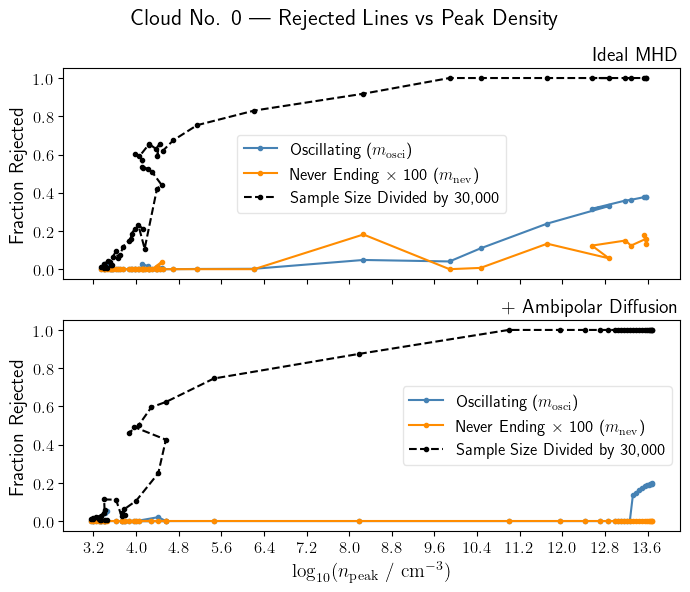

In [58]:
""" Fraction of Rejected as function of density"""

mpl.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{mathrsfs}'

row_titles = [r'Ideal MHD', r'+ Ambipolar Diffusion']
cases      = ["ideal", "amb"]
colors     = ["steelblue", "darkorange", "seagreen"]
labels     = [r"Oscillating ($m_{\rm osci}$)",
              r"Evaluated ($m_{\rm eval}$)",
              r"Never Ending $\times$ 100 ($m_{\rm nev}$)",
              r"Sample Size Divided by 30,000"]

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True, sharey=True)
fig.suptitle(r"Cloud No. 0 — Rejected Lines vs Peak Density", fontsize=FONTSIZE)

for ix, data in enumerate(dense_data):
    ax   = axes[ix]
    case = cases[ix]

    peaks  = np.array([get_peak_density_at(cloud=0, case=case, time=t_i)
                       for t_i in data["t"][::-1]])
    m_osci = np.array([np.nansum(f_i)/f_i.shape[0] for f_i in data["m_osci"][::-1]])
    m_nev  = np.array([100*np.nansum(~f_i)/f_i.shape[0] for f_i in data["m_nev"][::-1]])
    sizes = np.array([f_i.shape[0]/30_000 for f_i in data["m_osci"][::-1]])

    ax.plot(peaks, m_osci, ".-",color=colors[0], linewidth=1.5, label=labels[0])
    ax.plot(peaks, m_nev, ".-",  color=colors[1], linewidth=1.5, label=labels[2])
    ax.plot(peaks, sizes, ".--", color="black", linewidth=1.5, label=labels[3])

    #ax.set_xlim(3.1, 6)
    ax.set_ylabel(r"Fraction Rejected", fontsize=FONTSIZE - 2)
    ax.set_title(row_titles[ix], fontsize=FONTSIZE - 2, loc="right")
    ax.legend(fontsize=FONTSIZE - 4, framealpha=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=18))
    plt.setp(ax.get_xticklabels(), fontsize=FONTSIZE - 4)
    plt.setp(ax.get_yticklabels(), fontsize=FONTSIZE - 4)

axes[-1].set_xlabel(r"$\log_{10}(n_{\rm peak}\ /\ \rm{cm}^{-3})$", fontsize=FONTSIZE - 2)

plt.tight_layout()
#fig.savefig(f'../m-c-data/paper/FracRejected_c0.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

(30005, 3) (27541, 3) (22602, 3)
1
./data_points.pkl Does not Exists
dict_keys([np.int64(495), np.int64(400), np.int64(380)])
495 (30005, 3) (30005,)
400 (27541, 3) (27541,)
380 (22602, 3) (22602,)


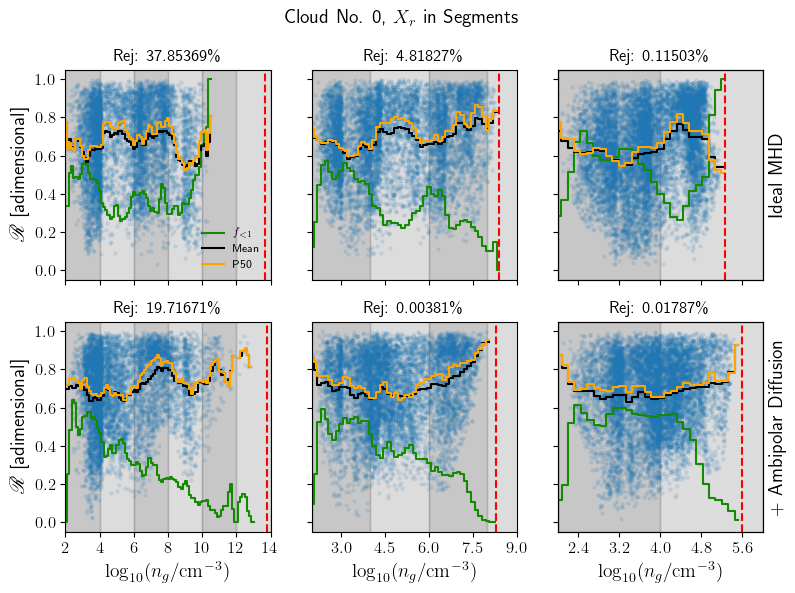

In [76]:
""" Reduction Factor vs Density Mosaic """

"""
The range of densities is not fully covered, we can observe that cells with densities above 10^9 cm^-3 are not present. 
To verify, I have in whatsapp some graphs and the `weighted.py` script to verify that the histogram of each distribution of the $X_r$ variable 
si generated differently, and $X_r ~ U_1$ does does not cover the range of densities to well, at least not in comparison with 
$X_r  ~ U_1 ^{3/2}$ which bulks more points near the center.

Both cases, the distribution was tested and the field lines were traced only to find that the final result with rejected lines does not, in fact,
reflects these previously stated distribution with present high densities. This points out, that traced lines rejected, contained the points 
in the sample generated at this cells with densities above 10^9.

In the ambipolar diffusion case no traced line was rejected, but in the ideal MHD around 700 lines were.

It was my bad to keep the upper bound of the radius as $0.1 \rm{pc}$

"""

mpl.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{mathrsfs}'

#print(ideal_set)
#print(non_ideal_set)
fig, axes = plt.subplots(2, 3, figsize=(3 * 3, 6), sharex='col', sharey=True)

fig.suptitle(f"Cloud No. 0,  $X_r$ in Segments", fontsize = FONTSIZE - 2)

cases = ["ideal", "amb"]

for ix, data in enumerate(dense_data): 
    ax = axes[ix,:]
    case = cases[ix]

    if ix == 0:
        #index = [index[0], index[10], index[16]]
        #rec   = [rec[0], rec[10], rec[16]]
        times  = [data["t"][::-1][0], data["t"][::-1][10], data["t"][::-1][12]]
        snaps  = [data["index"][::-1][0], data["index"][::-1][10], data["index"][::-1][12]]
        survs  = [data["surf"][::-1][0], data["surf"][::-1][10],data["surf"][::-1][12] ]
        n_ss   = [data["ns"][::-1][0], data["ns"][::-1][10], data["ns"][::-1][12]]
        r_us   = [data["ru"][::-1][0], data["ru"][::-1][10], data["ru"][::-1][12]]
        m_us   = [data["m_osci"][::-1][0], data["m_osci"][::-1][10], data["m_osci"][::-1][12]]

        print(data['x'][::-1][0].shape, data['x'][::-1][10].shape, data['x'][::-1][12].shape)

        data = {
            data["index"][::-1][0]: [data['x'][::-1][0], data["m_osci"][::-1][0]], 
            data["index"][::-1][10]: [data['x'][::-1][10], data["m_osci"][::-1][10]], 
            data["index"][::-1][12]: [data['x'][::-1][12], data["m_osci"][::-1][12]], 
            }

        metadata = {
            "Type": "Ideal MHD",
            "Created": str(np.datetime64("now")),
        }

        payload = {
            "data": data,
            "metadata": metadata,
        }
        print(len(list(glob.glob("./data_points.pkl"))))
        if not len(list(glob.glob("./data_points.pkl"))):
            print("./data_points.pkl Does not Exists")
            with open("data_points.pkl", "wb") as f:
                pickle.dump(payload, f)
        else:
            print("./data_points.pkl Does not Exists")
            with open("data_points.pkl", "rb") as f:
                payload = pickle.load(f)

            data = payload["data"]
            print(data.keys())
            for k, v in data.items():
                print(k, v[0].shape,v[1].shape)
            metadata = payload["metadata"]

        
    elif ix == 1:
        #index = [index[0], index[22], index[25]]
        #rec   = [rec[0], rec[22], rec[25]]      
        times  = [data["t"][::-1][0], data["t"][::-1][22], data["t"][::-1][23]]
        snaps  = [data["index"][::-1][0], data["index"][::-1][22], data["index"][::-1][23]]
        survs  = [data["surf"][::-1][0], data["surf"][::-1][22],data["surf"][::-1][23] ]
        n_ss   = [data["ns"][::-1][0], data["ns"][::-1][22], data["ns"][::-1][23]]
        r_us   = [data["ru"][::-1][0], data["ru"][::-1][22], data["ru"][::-1][23]]
        m_us   = [data["m_osci"][::-1][0], data["m_osci"][::-1][22], data["m_osci"][::-1][23]]

    max_den = [14, 9, 6]
    for j in range(3):

        ax[j].set_xlim(2, max_den[j])
        greys = [0.7, 0.5]
        for k, lo in enumerate(range(0, max_den[j]+2, 2)):
            axes[0, j].axvspan(lo, lo + 2, color=str(greys[k % 2]), alpha=0.25, zorder=0)
            axes[1, j].axvspan(lo, lo + 2, color=str(greys[k % 2]), alpha=0.25, zorder=0)



    for j, (t_i, f_i, n, r_u, m_s) in enumerate(zip(times, survs, n_ss, r_us, m_us)):

        #print("shapes: ", r_u.shape, n.shape, m_s.shape)
        r_full = r_u[~m_s]
        n_full = n[~m_s]
        criteria = 1/8
        #print("shapes: ", r_full.shape, n_full.shape, m_s.shape)
        #print(t_i, f_i, n.shape, r_u.shape, m_s.shape, case)
        val = get_peak_density_at(cloud=0, case=case, time = t_i)

        n_ref, mean_vec, median_vec, twofive_vec, ten_vec, five_vec, sample_size = red_to_den(r_full, n_full, criteria=criteria)

        mask_ = np.abs(np.log10(n_full)[np.newaxis, :] - np.log10(n_ref)[:, np.newaxis]) < (criteria)
        meet_condition = np.where(mask_, np.ones_like(r_full[np.newaxis, :]), 0)
        count_all = np.sum(meet_condition, axis=1) #/np.sum(meet_condition)

        f_l1 = 1.0 - np.sum(~m_s)/m_s.shape[0]
        mask = r_full < 1.0 #np.logical_and(, r_full > 0)
        r_u = r_full[mask]
        n_s = n_full[mask]
        total = r_full.shape[0]

        #ax[j].set_title(f"Time: {np.round(t_i, 5)} - Rej: {np.round(f_l1* 100.0, 5)}" + r"\%")
        ax[j].set_title(f"Rej: {np.round(f_l1* 100.0, 5)}" + r"\%")

        mask_ = np.abs(np.log10(n_s)[np.newaxis, :] - np.log10(n_ref)[:, np.newaxis]) < (criteria)
        meet_condition = np.where(mask_, np.ones_like(r_u[np.newaxis, :]), 0)
        count_lu = np.nansum(meet_condition, axis=1)
        count = count_lu / count_all
        count_zero = np.logical_and(count > 0.0, count < 1.0)

        ax[j].step(np.log10(n_ref), count, where = "mid", color=COLORS[1], label="$f_{<1}$")
        
        #print(count_all.shape, count_lu.shape, n_ref.shape)
        #print(np.min(np.log10(n_ref)))

        n_ref, mean_vec, median_vec, twofive_vec, ten_vec, five_vec, sample_size = red_to_den_keep_spacing(r_u, n_s, n_ref, criteria = 1/8)
        #n_ref, mean_vec, median_vec, twofive_vec, ten_vec, five_vec, sample_size = red_to_den(r_u, n_s, criteria=criteria)
        #print( np.min(np.log10(n_ref)))

        ax[j].step(np.log10(n_ref), mean_vec, where = "mid", linestyle="-",color="black", label="Mean")
        ax[j].step(np.log10(n_ref), median_vec, where = "mid", color="orange", label="P50")
        #ax[j].step(np.log10(n_ref), ten_vec, where = "mid", color=COLORS[2], label="P10")
        ax[j].scatter(np.log10(n_s), r_u, s=5, marker="o", alpha=0.1)
        ax[j].axvline(x=val + criteria,ymin=0, ymax=1, color='red', linestyle='--', linewidth=1.5)
        
        plt.setp(ax[j].get_xticklabels(), fontsize = FONTSIZE - 4)
        plt.setp(ax[j].get_yticklabels(), fontsize = FONTSIZE - 4)
        ax[j].xaxis.set_major_locator(MaxNLocator(nbins=6)) 

        if j == 0:
            ax[j].set_ylabel(r"$\mathscr{R}$ [adimensional]", fontsize = FONTSIZE - 2) # \mathscr{R}
            if ix == 0:
                ax[j].legend(fontsize = 8, frameon=False)

        if ix == 1:
            ax[j].set_xlabel(r"$\log_{10}(n_g / \rm{cm}^{-3})$", fontsize = FONTSIZE - 2)

        if (ix == 0 and j==2):
            axt = ax[j].twinx()
            axt.set_ylabel(r'Ideal MHD', fontsize= FONTSIZE - 2)
            axt.set_yticks([])  # hide the extra ticks/numbers
        if(ix == 1 and j==2):
            axt = ax[j].twinx()
            axt.set_ylabel(r'+ Ambipolar Diffusion', fontsize= FONTSIZE - 2)
            axt.set_yticks([])  # hide the extra ticks/numbers

    #imin = get_peak_density_at(cloud=idx, case="ideal", snap = int(ix)) + 0.5
    #ax.set_xscale("log")
    #amin = get_peak_density_at(cloud=idx, case="amb", snap = int(ix)) + 0.5
    #
    #ax.set_xscale("log")

#pcm.set_rasterized(True)  # or rasterized=True when creating it
#fig.savefig(f'../m-c-data/paper/ScatterRvN_Selected_Segments_c0.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

In [ ]:
""" Rejected Fraction vs Density Mosaic """

""" Plot Fraction of Rejected Lines per density bin """

mpl.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{mathrsfs}'

fig, axes = plt.subplots(2, 3, figsize=(3 * 3, 6), sharex='col', sharey=True)

fig.suptitle(f"Cloud No. 0,  $X_r$ in Segments", fontsize = FONTSIZE - 2)

cases = ["ideal", "amb"]

for ix, data in enumerate(dense_data): 
    ax = axes[ix,:]
    case = cases[ix]

    if ix == 0:
        #index = [index[0], index[10], index[16]]
        #rec   = [rec[0], rec[10], rec[16]]
        times  = [data["t"][::-1][0], data["t"][::-1][10], data["t"][::-1][12]]
        snaps  = [data["index"][::-1][0], data["index"][::-1][10], data["index"][::-1][12]]
        survs  = [data["surf"][::-1][0], data["surf"][::-1][10],data["surf"][::-1][12] ]
        n_ss   = [data["ns"][::-1][0], data["ns"][::-1][10], data["ns"][::-1][12]]
        r_us   = [data["ru"][::-1][0], data["ru"][::-1][10], data["ru"][::-1][12]]
        m_us   = [data["m_osci"][::-1][0], data["m_osci"][::-1][10], data["m_osci"][::-1][12]]
        
    elif ix == 1:
        #index = [index[0], index[22], index[25]]
        #rec   = [rec[0], rec[22], rec[25]]      
        times  = [data["t"][::-1][0], data["t"][::-1][22], data["t"][::-1][23]]
        snaps  = [data["index"][::-1][0], data["index"][::-1][22], data["index"][::-1][23]]
        survs  = [data["surf"][::-1][0], data["surf"][::-1][22],data["surf"][::-1][23] ]
        n_ss   = [data["ns"][::-1][0], data["ns"][::-1][22], data["ns"][::-1][23]]
        r_us   = [data["ru"][::-1][0], data["ru"][::-1][22], data["ru"][::-1][23]]
        m_us   = [data["m_osci"][::-1][0], data["m_osci"][::-1][22], data["m_osci"][::-1][23]]

    max_den = [14, 9, 6]
    
    for j in range(3):

        ax[j].set_xlim(-1, max_den[j])
        greys = [0.7, 0.5]
        for k, lo in enumerate(range(0, max_den[j]+2, 2)):
            axes[0, j].axvspan(lo, lo + 2, color=str(greys[k % 2]), alpha=0.25, zorder=0)
            axes[1, j].axvspan(lo, lo + 2, color=str(greys[k % 2]), alpha=0.25, zorder=0)

    for j, (t_i, f_i, n, r_u, m_s) in enumerate(zip(times, survs, n_ss, r_us, m_us)):

        #ax[j].scatter(np.log10(n), r_u, s=5, marker="o", alpha=0.1)


        criteria = 1/4
        val = get_peak_density_at(cloud=0, case=case, time = t_i)

        # binning with rejected values
        n_ref, mean_vec, median_vec, twofive_vec, ten_vec, five_vec, sample_size = red_to_den(r_u, n, criteria=criteria)

        # bin all data, rejected + survivors
        mask_ = np.abs(np.log10(n)[np.newaxis, :] - np.log10(n_ref)[:, np.newaxis]) < (criteria)
        meet_condition = np.where(mask_, np.ones_like(r_u[np.newaxis, :]), 0)

        # and count all data in each bin
        count_all = np.sum(meet_condition, axis=1) # /np.sum(meet_condition)

        # now, observe how much data was rejected
        f_l1 = np.sum(m_s)/m_s.shape[0]
        r_filter = r_u[m_s]
        n_filter = n[m_s]

        # plot total percentage of rejected values in the snapshot
        ax[j].set_title(f"Rej: {np.round(f_l1* 100.0, 5)}" + r"\%")

        # now, get the count of rejected values on reach bin (use previous n_ref)
        mask_ = np.abs(np.log10(n_filter)[np.newaxis, :] - np.log10(n_ref)[:, np.newaxis]) < (criteria)
        meet_condition = np.where(mask_, np.ones_like(r_filter[np.newaxis, :]), 0)
        count_lu = np.nansum(meet_condition, axis=1)
        count = count_lu / count_all
        print(np.nansum(count_lu)*100/n.shape[0])
        #count_zero = np.logical_and(count > 0.0, count < 1.0)
    
        #n_ref2, mean_vec, median_vec, twofive_vec, ten_vec, five_vec, sample_size = red_to_den_keep_spacing(r_filter, n_filter, n_ref, criteria = 1/8)
        #print(np.nansum(count_lu), np.nansum(count_all))
    
        ax[j].plot(np.log10(n_ref), count, linestyle="-",color="black", label="Rejected per bin")

        ax[j].axvline(x=val + criteria,ymin=0, ymax=1, color='red', linestyle='--', linewidth=1.5)
        
        plt.setp(ax[j].get_xticklabels(), fontsize = FONTSIZE - 4)
        plt.setp(ax[j].get_yticklabels(), fontsize = FONTSIZE - 4)
        ax[j].xaxis.set_major_locator(MaxNLocator(nbins=6)) 

        if j == 0:
            ax[j].set_ylabel(r"$\mathscr{R}$ [adimensional]", fontsize = FONTSIZE - 2) # \mathscr{R}
            if ix == 0:
                ax[j].legend(fontsize = 8, frameon=False)

        if ix == 1:
            ax[j].set_xlabel(r"$\log_{10}(n_g / \rm{cm}^{-3})$", fontsize = FONTSIZE - 2)

        if (ix == 0 and j==2):
            axt = ax[j].twinx()
            axt.set_ylabel(r'Ideal MHD', fontsize= FONTSIZE - 2)
            axt.set_yticks([])  # hide the extra ticks/numbers
        if(ix == 1 and j==2):
            axt = ax[j].twinx()
            axt.set_ylabel(r'+ Ambipolar Diffusion', fontsize= FONTSIZE - 2)
            axt.set_yticks([])  # hide the extra ticks/numbers


#pcm.set_rasterized(True)  # or rasterized=True when creating it
#fig.savefig(f'../m-c-data/paper/ScatterRvN_Selected_Segments_c0.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.00037787182587666263
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.001815475109836244
NeverEnding:  0.0
NeverEnding:  6.665555740709882e-05
NeverEnding:  0.0013331111481419764
NeverEnding:  0.0005665722379603399
NeverEnding:  0.0012331278120313281
NeverEnding:  0.0014997500416597234
NeverEnding:  0.0012331278120313281
NeverEndin

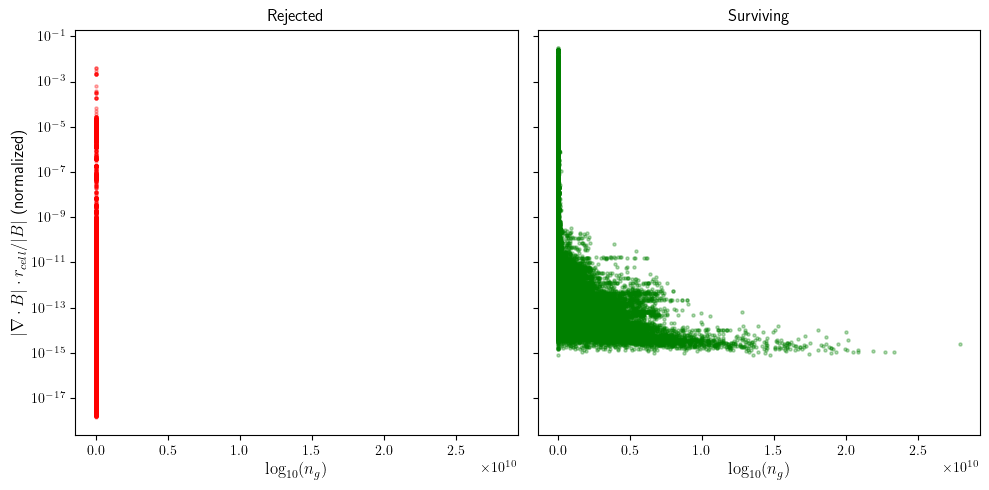

NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0
NeverEnding:  0.0


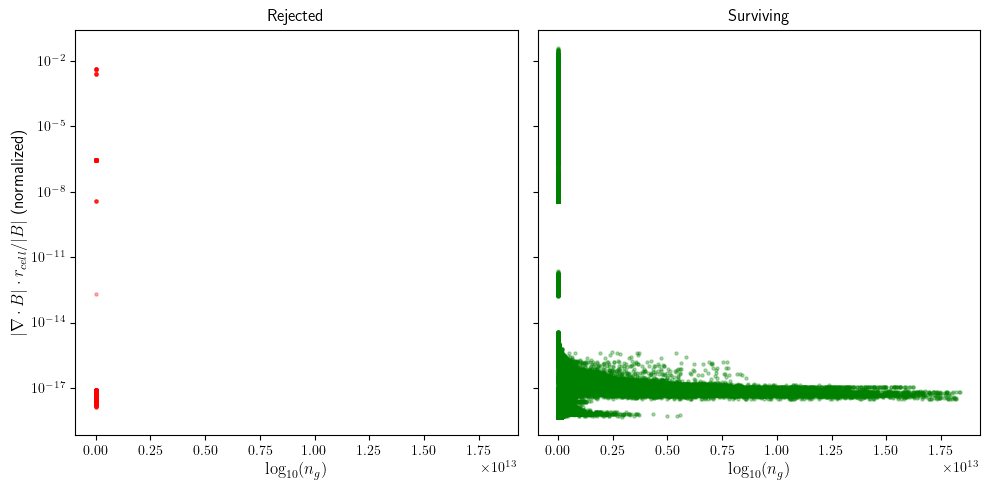

In [77]:
for data in dense_data:

    fig, (ax_rej, ax_surv) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

    for tindex, time in enumerate(data["t"]):

        #print(time)
        #print("Oscilations: ", np.sum(data["m_osci"][tindex]) / data["m_osci"][tindex].shape[0])
        print("NeverEnding: ", np.sum(~data["m_nev"][tindex]) / data["m_nev"][tindex].shape[0])
        mask      = ~data["m_osci"][tindex].astype(bool)
        densities = data["ns"][tindex]
        NormDivB  = data["ndivv"][tindex]

        surv_densities = densities[mask]
        rej_densities  = densities[~mask]

        surv_div       = np.abs(NormDivB[mask])
        rej_div        = np.abs(NormDivB[~mask])

        ax_rej.scatter(rej_densities,  rej_div,  s=5, color="r", alpha=0.3)
        ax_surv.scatter(surv_densities, surv_div, s=5, color="g", alpha=0.3)

    for ax, title in zip([ax_rej, ax_surv], ["Rejected", "Surviving"]):
        ax.set_yscale("log")
        ax.set_xlabel(r"$\log_{10}(n_g)$", fontsize=12)
        ax.set_title(title)

    ax_rej.set_ylabel(r"$|\nabla \cdot B| \cdot r_{cell} / |B|$ (normalized)", fontsize=12)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

0.125
Oscilations  :  [0.015625]
0.25
Oscilations  :  [0.02553191]
0.375
Oscilations  :  [0.]
0.48750000000000004
Oscilations  :  [0.00178571]
0.5750000000000001
Oscilations  :  [0.00236967]
0.65
Oscilations  :  [0.00562701]
0.775
Oscilations  :  [0.]
0.8625
Oscilations  :  [0.]
0.9625
Oscilations  :  [0.]
1.0875000000000001
Oscilations  :  [0.]
1.1625
Oscilations  :  [0.]
1.2875
Oscilations  :  [0.]
1.4000000000000001
Oscilations  :  [0.]
1.5250000000000001
Oscilations  :  [0.]
1.64375
Oscilations  :  [0.]
1.70625
Oscilations  :  [0.]
1.78125
Oscilations  :  [0.]
1.9000000000000001
Oscilations  :  [0.]
2.0125
Oscilations  :  [0.]
2.1375
Oscilations  :  [0.]
2.2625
Oscilations  :  [0.]
2.3875
Oscilations  :  [0.]
2.5125
Oscilations  :  [0.00816203]
2.6375
Oscilations  :  [0.]
2.7625
Oscilations  :  [0.01422855]
2.8875
Oscilations  :  [0.02945205]
3.0125
Oscilations  :  [0.00558274]
3.1375
Oscilations  :  [0.00476938]
3.2625
Oscilations  :  [0.]
3.375
Oscilations  :  [0.]
3.5
Oscilation

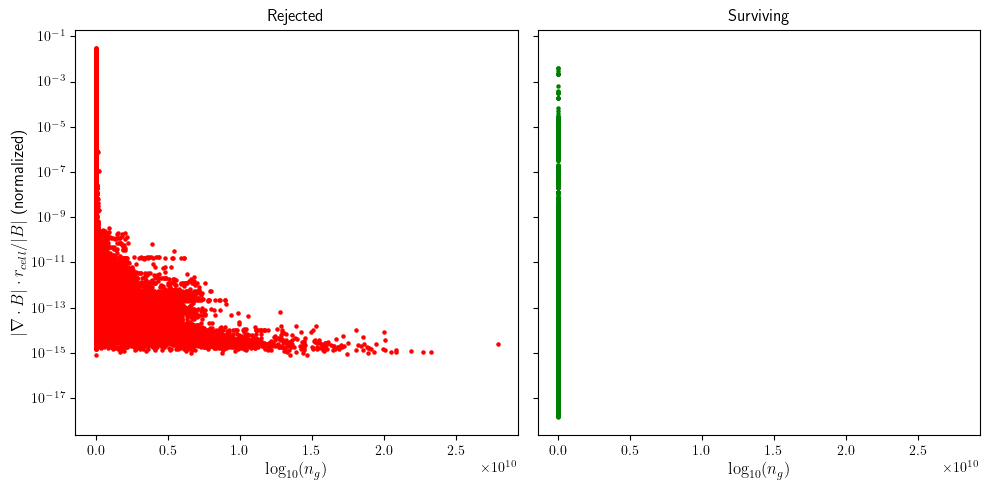

0.125
Oscilations  :  [0.05109489]
0.25
Oscilations  :  [0.04411765]
0.375
Oscilations  :  [0.]
0.5
Oscilations  :  [0.]
0.625
Oscilations  :  [0.]
0.75
Oscilations  :  [0.]
0.875
Oscilations  :  [0.]
1.0
Oscilations  :  [0.]
1.125
Oscilations  :  [0.]
1.25
Oscilations  :  [0.]
1.375
Oscilations  :  [0.]
1.5
Oscilations  :  [0.]
1.5875000000000001
Oscilations  :  [0.]
1.7125000000000001
Oscilations  :  [0.]
1.8375000000000001
Oscilations  :  [0.]
1.9625000000000001
Oscilations  :  [0.]
2.0875
Oscilations  :  [0.]
2.2125
Oscilations  :  [0.]
2.3375
Oscilations  :  [0.]
2.4875000000000003
Oscilations  :  [0.0206474]
2.725
Oscilations  :  [0.]
2.95
Oscilations  :  [0.]
3.2
Oscilations  :  [0.]
3.45
Oscilations  :  [0.]
3.7
Oscilations  :  [0.]
3.95
Oscilations  :  [0.]
4.2
Oscilations  :  [0.00017871]
4.28671875
Oscilations  :  [3.81155664e-05]
4.29013671875
Oscilations  :  [0.]
4.290350341796875
Oscilations  :  [0.]
4.2903991699218755
Oscilations  :  [0.]
4.29041748046875
Oscilations  : 

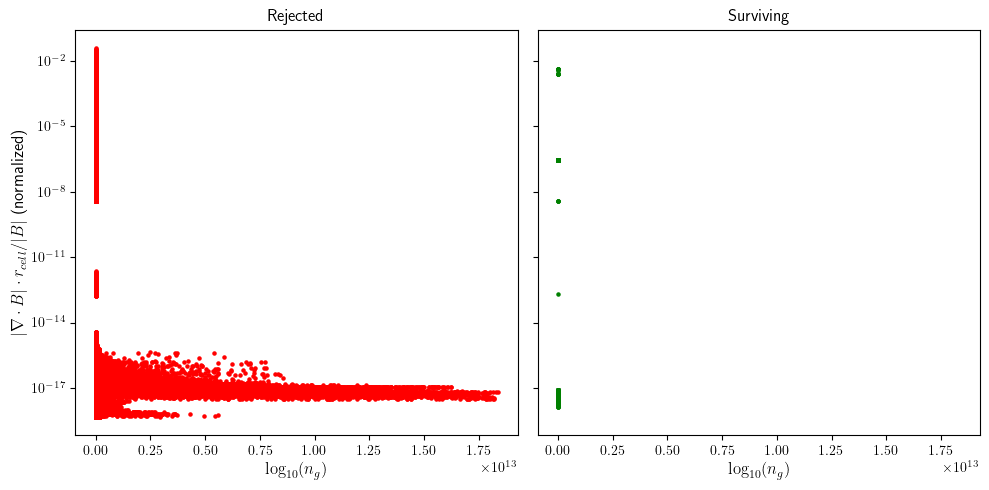

In [ ]:

for data in dense_data:

    fig, axd = plt.subplot_mosaic(
        [["Rejected", "Surviving"]],
        figsize=(10, 5),
        sharex=True,
        sharey=True,
    )
    total = 0
    
    for tindex, time in enumerate(data["t"]):

        print(time)
        print("Oscilations  : ", np.sum(data["m_osci"][tindex] )/data["m_osci"][tindex].shape)
        #print("NeverEnding  : ", np.sum(~data["m_nev"][tindex])/data["m_nev"][tindex].shape)
        #print("EvalReduction: ", np.sum(data["m_eval"][tindex])/data["m_eval"][tindex].shape)


        mask = data["m_osci"][tindex]# np.logical_and(data["m_osci"][tindex], data["m_osci"][tindex])
        #print(mask)
        densities = data["ns"][tindex]
        NormDivB = data["ndivv"][tindex]

        surv_densities = densities[mask] # [mask]
        rej_densities = densities[np.logical_not(mask)] #[np.logical_not(mask)]
        #print(surv_densities.shape)
        total += surv_densities.shape[0]
        surv_div = abs(NormDivB[mask]) # [mask]
        rej_div = abs(NormDivB[np.logical_not(mask)]) # [np.logical_not(mask)]

        axd["Rejected"].scatter(rej_densities, rej_div, s=5, color="r")
        axd["Surviving"].scatter(surv_densities, surv_div, s=5, color="g")

    for name, ax in axd.items():
        ax.set_yscale("log")
        ax.set_xlabel(r"$\log_{10}(n_g)$", fontsize=12)
        ax.set_title(name)

    axd["Rejected"].set_ylabel(r"$|\nabla \cdot B| \cdot r_{cell} / |B|$ (normalized)", fontsize=12)

    fig.tight_layout()
    plt.show()


## Repeat with series

In [ ]:
def imporfromfile(file, identifier):

    df = pd.read_pickle(file)
    df.index.name = 'snapshot'
    df.index = df.index.astype(int)
    df = df.sort_index()
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_colwidth', None)
    #print(df)
    try:
        t     = df["time"].to_numpy()
        #print("Non-Empty:", file.split("/")[-1])        
    except:
        print("Empty:", file.split("/")[-1])
        return None
    _ = np.argsort(t)
    # dict_keys(['time', 'surv_mask', 'x_input', 'n_rs', 'B_rs', 'norm_divb', 'directions', 'B_s', 'r_s', 'n_s', 'surv_fraction'])
    #                    "norm_divb": NormDivB,
    #            "norm_divn": NormDivDensity,
    t     = df["time"].to_numpy()[_]
    mask  = df["surv_mask"].to_numpy()[_]
    x     = df["x_input"].to_numpy()[_]
    #n     = df["n_s"].to_numpy()[_]
    #B     = df["B_s"].to_numpy()[_]
    #rs    = df["r_s"].to_numpy()[_]
    ns    = df["n_rs"].to_numpy()[_]
    Bs    = df["B_rs"].to_numpy()[_]
    ndivb = df["norm_divb"].to_numpy()[_]
    ndivN = df["norm_divn"].to_numpy()[_]
    surf  = df["surv_fraction"].to_numpy()[_]

    radius = []
    for ris in x:
        if ris.shape[0] == 0:
            continue
        radius += [np.max(np.linalg.norm(ris, axis=1))]

    if identifier == '2i0' or identifier == '2a0':
        radius = 0.1
        
    return {
        "id": identifier,
        "rloc": radius,
        "m":     mask,
        "t":     t,
        "x":     x,
#        "n":     n,
#        "B":     B,
#        "rs":     rs,
        "ns":     ns,
        "Bs":     Bs,
        "surf":  surf,
        "ndivb":  ndivb,
        "ndivn": ndivN
    }



In [ ]:
#files = list(sorted(glob.glob(f'/home/leni/magnetic_pockets/m-c-stats/lines/*w*.pkl')))
files = list(sorted(glob.glob(f'/home/leni/magnetic_pockets/m-c-stats/series/*_dense/*dense.pkl')))
# excluding weighted and multiple clouds

for file in files:
    print(file)

/home/leni/magnetic_pockets/m-c-stats/series\a0_dense\data_2a0_dense.pkl
/home/leni/magnetic_pockets/m-c-stats/series\i0_dense\data_2i0_dense.pkl


    Index(['snapshot', 'time', 'surv_mask', 'x_input', 'norm_divb', 'norm_divn',
        'n_rs', 'B_rs', 'n_path', 'n_los0', 'n_los1', 'surv_fraction', 'r_u',
        'r_l'], dtype='object')

In [ ]:
if files:    
    config = {}
    for file in files:

        if "tmp" in file:
            continue

        #print(file)

        ID = file.split('.')[-2][-10:]

        #os.makedirs(f"./series/{ID}", exist_ok=True)
        something = imporfromfile(file, ID)

        if something is None:
            continue

        config[f'data{ID}'] = something
        print(f'data{ID}')

    globals().update(config) # This injects every key as a variable in your script

KeyError: 'surv_mask'

# This Notebook is used to explore the output of local tests. More explicitly,

- The results of the flag `-lin`, `-dense`, `-weight`
- Check the validity of the distribution at used. With or without weight.
- Check the validity of the field lines obtained, as well as the 

# Shape of Magnetic Field Profiles

In [ ]:
def Linesimporfromfile(file, identifier):

    df = pd.read_pickle(file)
    df.index.name = 'snapshot'
    df.index = df.index.astype(int)
    df = df.sort_index()
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_colwidth', None)
    #print(df)
    try:
        t     = df["time"].to_numpy()
        #print("Non-Empty:", file.split("/")[-1])        
    except:
        print("Empty:", file.split("/")[-1])
        return None
    _ = np.argsort(t)
    # ['snapshot', 'time', 'surv_mask', 'x_input', 'n_rs', 'B_rs', 'norm_divb', 'directions', 'B_s', 'r_s', 'n_s', 'surv_fraction']
    t     = df["time"].to_numpy()[_]
    mask  = df["surv_mask"].to_numpy()[_]
    x     = df["x_input"].to_numpy()[_]
    n     = df["n_s"].to_numpy()[_]
    B     = df["B_s"].to_numpy()[_]
    rs    = df["r_s"].to_numpy()[_]
    #ns    = df["n_rs"].to_numpy()[_]
    #Bs    = df["B_rs"].to_numpy()[_]
    NormDivB = df['norm_divb'].to_numpy()[_]
    
    surf  = df["surv_fraction"].to_numpy()[_]
    print(df.columns.tolist())
    #print(df)
    radius = []
    for ris in x:
        if ris.shape[0] == 0:
            continue
        radius += [np.max(np.linalg.norm(ris, axis=1))]

    if identifier == '2i0' or identifier == '2a0':
        radius = 0.1
    
    return {
        "id": identifier,
        "rloc": radius,
        "m":     mask,
        "t":     t,
        "x":     x,
        "n":     n,
        "B":     B,
        "rs":     rs,
        "surf":  surf
    }



In [ ]:
files = list(sorted(glob.glob(f'/home/leni/magnetic_pockets/m-c-stats/lines/data*w*.pkl')))

# excluding weighted and multiple clouds
for file in files:
    print(file)


/home/leni/magnetic_pockets/m-c-stats/lines\data_2wa0.pkl
/home/leni/magnetic_pockets/m-c-stats/lines\data_2wi0.pkl


In [ ]:
if files:    
    config = {}
    for file in files:

        if "tmp" in file:
            continue

        #print(file)

        ID = file.split('.')[-2][-3:]

        #os.makedirs(f"./series/{ID}", exist_ok=True)
        something = Linesimporfromfile(file, ID)

        if something is None:
            continue

        config[f'data{ID}'] = something
        print(f'data{ID}')

    globals().update(config) # This injects every key as a variable in your script

['snapshot', 'time', 'surv_mask', 'x_input', 'n_rs', 'B_rs', 'norm_divb', 'directions', 'B_s', 'r_s', 'n_s', 'surv_fraction']
datawa0
['snapshot', 'time', 'surv_mask', 'x_input', 'n_rs', 'B_rs', 'norm_divb', 'directions', 'B_s', 'r_s', 'n_s', 'surv_fraction']
datawi0


4.5515625
4.55206298828125


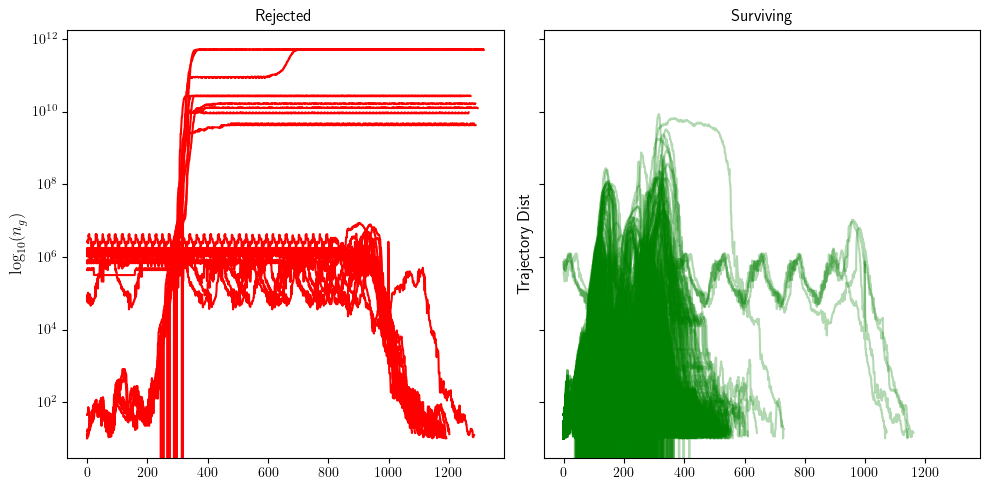

4.290350341796875
4.290492248535156


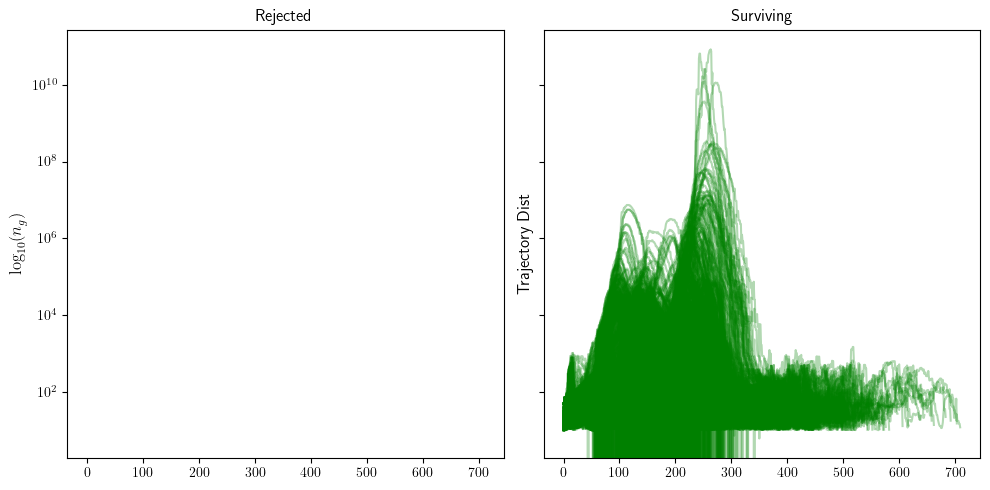

In [ ]:
from collections import Counter

datas = [datawi0, datawa0]
for data in datas:

    fig, axd = plt.subplot_mosaic(
        [["Rejected", "Surviving"]],
        figsize=(10, 5),
        sharex=True,
        sharey=True,
    )

    for tindex, time in enumerate(data["t"]):

        mask = data["m"][tindex]
        densities = data["n"][tindex]#[mask]
        fields    = data["B"][tindex]#[mask]
        vectors   = data["rs"][tindex]#[mask]
        x_input   = data["rs"][tindex]#[mask]
        print(time)

        for line in range(0, densities.shape[1], 1):

            mask_rej = mask[line]

            dens = densities[:, line]
            indexes = np.where(dens > 10) # where is the field line reaching the threshold of 100cm-3
            first, last = indexes[0][0], indexes[0][-1]
            field = fields[first:last, line]
            dens = densities[first:last, line] 
            vector = vectors[first:last, line, :] 
            segment_lengths = np.linalg.norm(np.diff(vector, axis=0), axis=1)
            distances = np.concatenate([np.zeros((1, )), np.cumsum(segment_lengths, axis=0)], axis=0)  # shape (1999)


            if mask_rej == True:
                #axd["Surviving"].plot(distances, field, '-', color="g")
                axd["Surviving"].plot(dens, '-', color="g", alpha = 0.3)

            else:    
                count = Counter(dens)
                #print(count.most_common(3))
                #axd["Rejected"].plot(distances, field, '-', color="r")
                axd["Rejected"].plot(dens, '-', color="r")



    for name, ax in axd.items():
        ax.set_yscale("log")
        #ax.set_xscale("log")
        ax.set_ylabel(r"Trajectory Dist", fontsize=12)
        ax.set_title(name)

    axd["Rejected"].set_ylabel(r"$\log_{10}(n_g)$", fontsize=12)

    fig.tight_layout()
    plt.show()

4.5515625
4.55206298828125


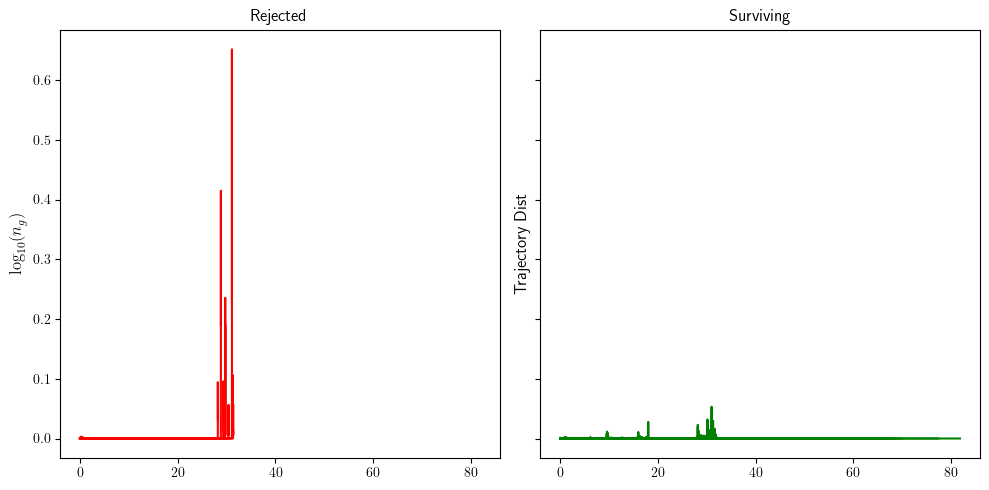

4.290350341796875
4.290492248535156


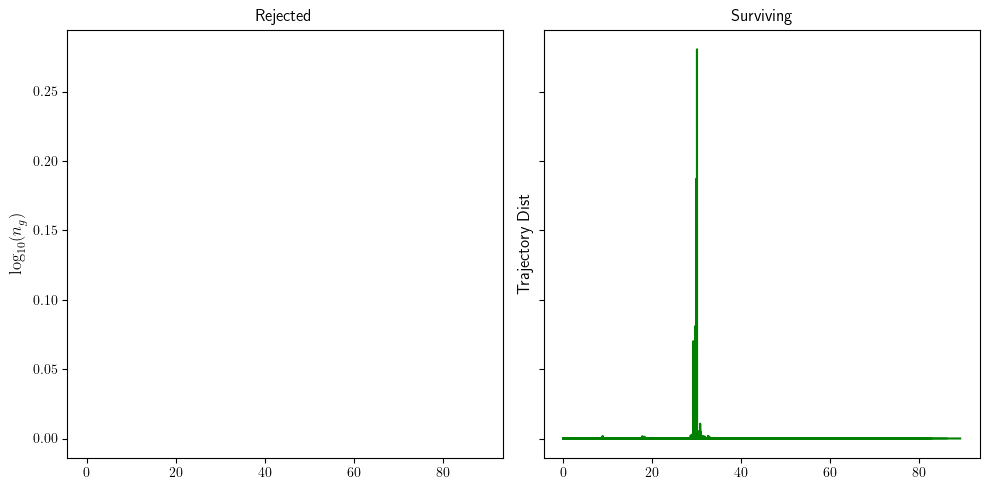

In [ ]:
from collections import Counter

datas = [datawi0, datawa0]
for data in datas:

    fig, axd = plt.subplot_mosaic(
        [["Rejected", "Surviving"]],
        figsize=(10, 5),
        sharex=True,
        sharey=True,
    )

    for tindex, time in enumerate(data["t"]):

        mask = data["m"][tindex]
        densities = data["n"][tindex]#[mask]
        fields    = data["B"][tindex]#[mask]
        vectors   = data["rs"][tindex]#[mask]
        x_input   = data["rs"][tindex]#[mask]
        print(time)

        for line in range(0, densities.shape[1], 1):

            mask_rej = mask[line]

            dens = densities[:, line]
            indexes = np.where(dens > 10) # where is the field line reaching the threshold of 100cm-3
            first, last = indexes[0][0], indexes[0][-1]
            field = fields[first:last, line]
            dens = densities[first:last, line] 
            vector = vectors[first:last, line, :] 
            segment_lengths = np.linalg.norm(np.diff(vector, axis=0), axis=1)
            distances = np.concatenate([np.zeros((1, )), np.cumsum(segment_lengths, axis=0)], axis=0)  # shape (1999)
            
            is_there_zeroes = dens != 0

            if mask_rej == True:
                axd["Surviving"].plot(distances, field, '-', color="g")
                #axd["Surviving"].plot(is_there_zeroes, '-', color="g", alpha = 0.3)

            else:    
                count = Counter(dens)
                #print(count.most_common(3))
                axd["Rejected"].plot(distances, field, '-', color="r")
                #axd["Rejected"].plot(is_there_zeroes, '-', color="r")



    for name, ax in axd.items():
        #ax.set_yscale("log")
        #ax.set_xscale("log")
        ax.set_ylabel(r"Trajectory Dist", fontsize=12)
        ax.set_title(name)

    axd["Rejected"].set_ylabel(r"$\log_{10}(n_g)$", fontsize=12)

    fig.tight_layout()
    plt.show()

(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
[(np.float64(703483.8550895829), 258), (np.float64(674916.2479536664), 235), (np.float64(808352.0767941247), 78)]
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
(1999, 500)
[(np.float64(27341606451.720932), 321), (np.float64(26953892631.4471), 239), (np.float64(26711394767.491676), 216)]
(1999, 500)
[(np.float64(703483.8550895829), 155), (np.float64(674916.2479536664), 138), (np.float64(764635.7800870356), 5

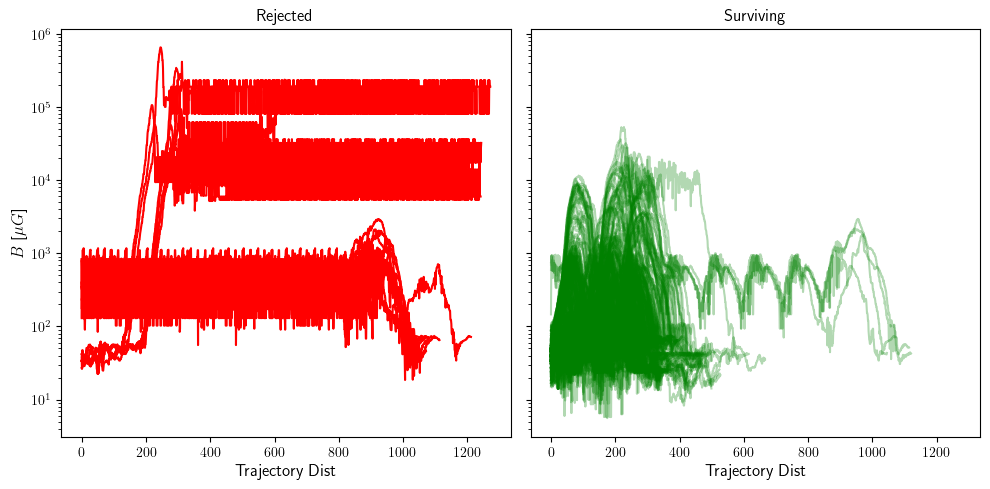

(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)
(765, 500)

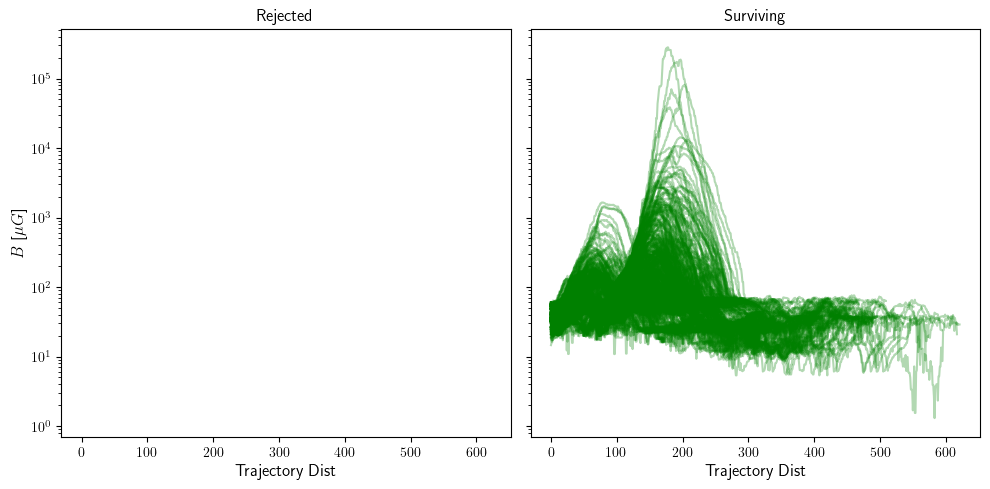

In [ ]:
from collections import Counter

datas = [datawi0, datawa0]
for data in datas:

    fig, axd = plt.subplot_mosaic(
        [["Rejected", "Surviving"]],
        figsize=(10, 5),
        sharex=True,
        sharey=True,
    )

    for tindex, time in enumerate(data["t"]):

        mask = data["m"][tindex]
        densities = data["n"][tindex]#[mask]
        fields    = data["B"][tindex]#[mask]
        vectors   = data["rs"][tindex]#[mask]

        for line in range(0, densities.shape[1], 1):

            mask_rej = mask[line]

            dens = densities[:, line]
            print(densities.shape)
            indexes = np.where(dens > 100) # where is the field line reaching the threshold of 100cm-3
            first, last = indexes[0][0], indexes[0][-1]
            field = fields[first:last, line]
            dens = densities[first:last, line] 
            vector = vectors[first:last, line, :] 
            segment_lengths = np.linalg.norm(np.diff(vector, axis=0), axis=1)
            distances = np.concatenate([np.zeros((1, )), np.cumsum(segment_lengths, axis=0)], axis=0)  # shape (1999)

            if mask_rej == True:
                #axd["Surviving"].plot(distances, field, '-', color="g")
                axd["Surviving"].plot(field*1.0e+6, '-', color="g", alpha = 0.3)
            else:    
                count = Counter(dens)
                print(count.most_common(3))
                #axd["Rejected"].plot(distances, field, '-', color="r")
                axd["Rejected"].plot(field*1.0e+6, '-', color="r")

    for name, ax in axd.items():
        ax.set_yscale("log")
        #ax.set_xscale("log")
        ax.set_xlabel(r"Trajectory Dist", fontsize=12)
        ax.set_title(name)
    
    axd["Rejected"].set_ylabel(r"$B$ [$\mu G$]", fontsize=12)

    fig.tight_layout()
    plt.show()

dict_keys(['id', 'rloc', 'm', 't', 'x', 'n', 'B', 'rs', 'surf'])


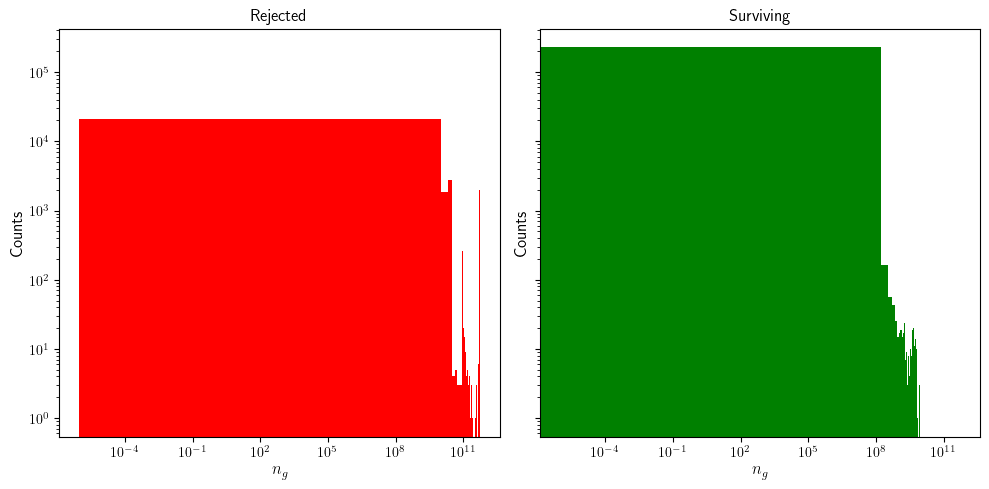

dict_keys(['id', 'rloc', 'm', 't', 'x', 'n', 'B', 'rs', 'surf'])


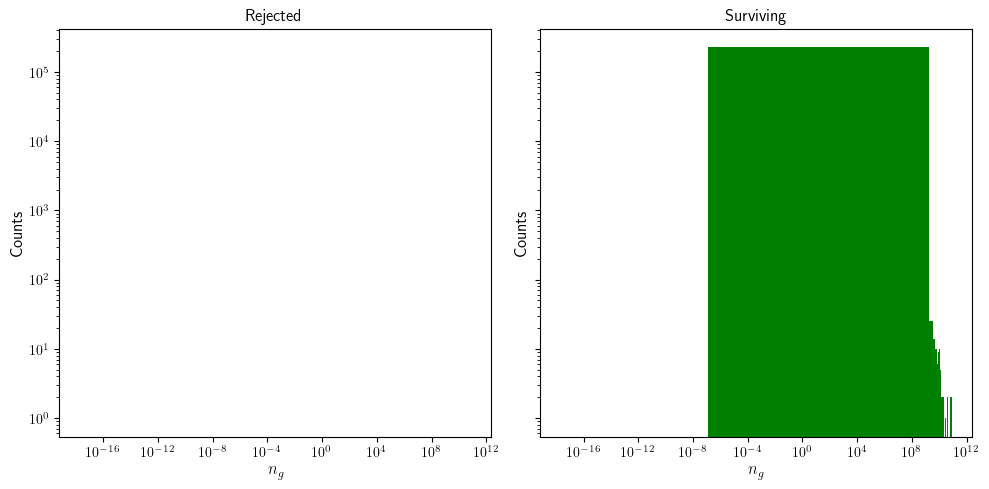

In [ ]:
from collections import Counter
import numpy as np

datas = [datawi0, datawa0]
for data in datas:

    fig, axd = plt.subplot_mosaic(
        [["Rejected", "Surviving"]],
        figsize=(10, 5),
        sharex=True,
        sharey=True,
    )

    # accumulate density values across all lines/times, split by category
    dens_surviving = []
    dens_rejected = []
    print(data.keys())

    for tindex, time in enumerate(data["t"]):

        mask = data["m"][tindex]
        densities = data["n"][tindex]

        for line in range(0, densities.shape[1], 1):

            mask_rej = mask[line]

            dens = densities[:, line]
            indexes = np.where(dens > 100)
            first, last = indexes[0][0], indexes[0][-1]
            dens = densities[first:last, line]

            if mask_rej:
                dens_surviving.extend(dens)
            else:
                dens_rejected.extend(dens)

    # plot once per category, using proper binning
    axd["Surviving"].hist(dens_surviving, bins=50, color="g", density=False)
    axd["Rejected"].hist(dens_rejected, bins=50, color="r", density=False)

    for name, ax in axd.items():
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_xlabel(r"$n_g$", fontsize=12)
        ax.set_ylabel("Counts", fontsize=12)
        ax.set_title(name)

    fig.tight_layout()
    plt.show()

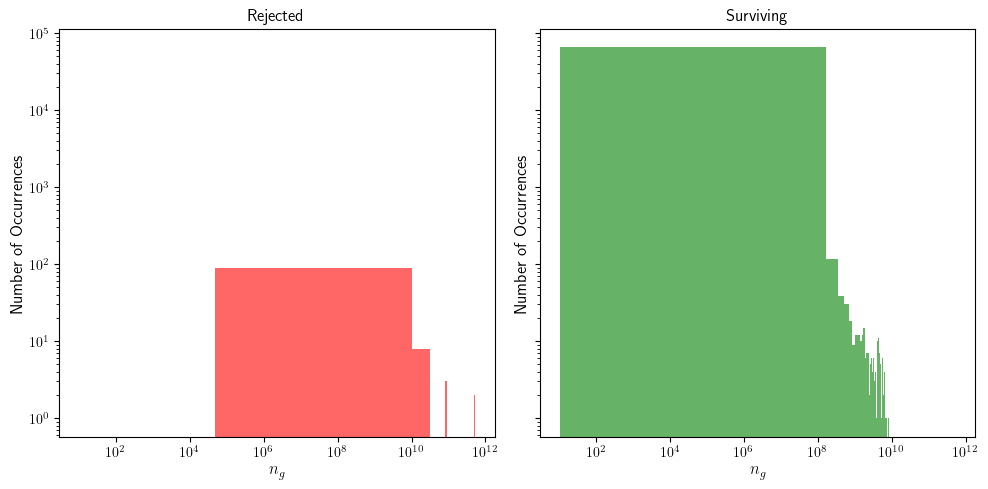

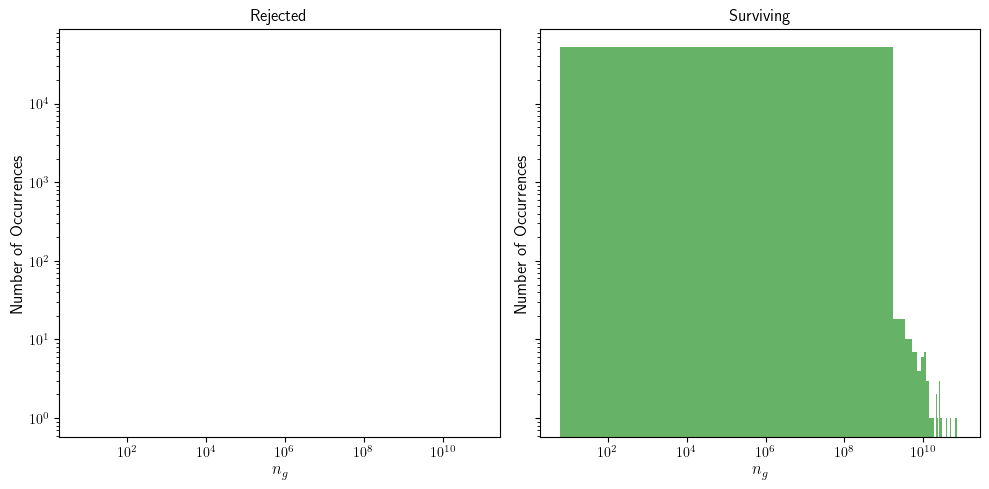

In [ ]:
from collections import Counter
import numpy as np

datas = [datawi0, datawa0]
for data in datas:

    fig, axd = plt.subplot_mosaic(
        [["Rejected", "Surviving"]],
        figsize=(10, 5),
        sharex=True,
        sharey=True,
    )

    dens_surviving = []
    dens_rejected = []

    for tindex, time in enumerate(data["t"]):

        mask = data["m"][tindex]
        densities = data["n"][tindex]

        for line in range(0, densities.shape[1], 1):

            mask_rej = mask[line]

            dens = densities[:, line]
            indexes = np.where(dens > 100)
            first, last = indexes[0][0], indexes[0][-1]
            dens = densities[first:last, line]

            if mask_rej == True:
                dens_surviving.extend(dens)
            else:
                dens_rejected.extend(dens)

    # count occurrences across ALL lines/times combined, per category
    counts_surviving = Counter(dens_surviving)
    counts_rejected = Counter(dens_rejected)

    # keep only values that repeat (frequency >= 2)
    rep_surviving = {v: f for v, f in counts_surviving.items() if f < 20}
    rep_rejected  = {v: f for v, f in counts_rejected.items() if f >= 20}

    if rep_surviving:
        vals_s, freq_s = zip(*sorted(rep_surviving.items()))
        axd["Surviving"].hist(vals_s, bins = 50,color="g", alpha=0.6)

    if rep_rejected:
        vals_r, freq_r = zip(*sorted(rep_rejected.items()))
        axd["Rejected"].hist(vals_r, bins = 50, color="r", alpha=0.6)

    for name, ax in axd.items():
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_xlabel(r"$n_g$", fontsize=12)
        ax.set_ylabel("Number of Occurrences", fontsize=12)
        ax.set_title(name)

    fig.tight_layout()
    plt.show()
    

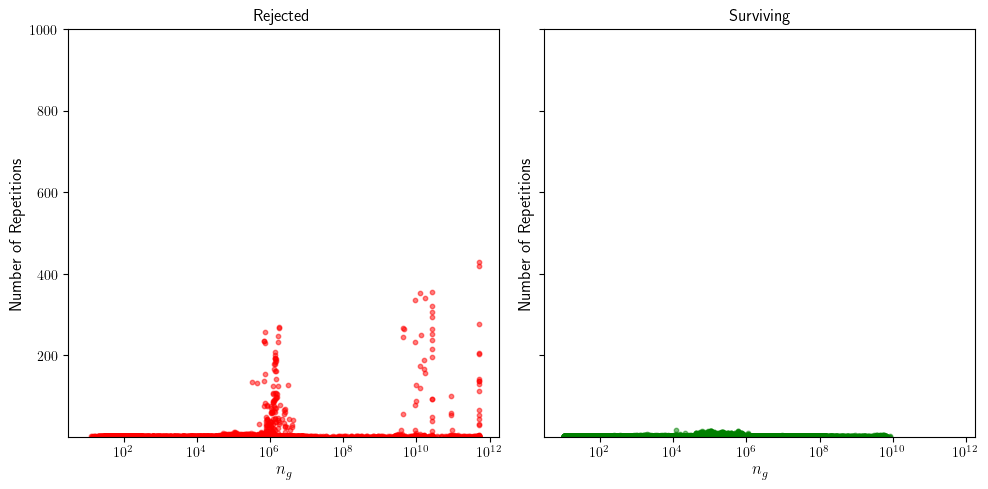

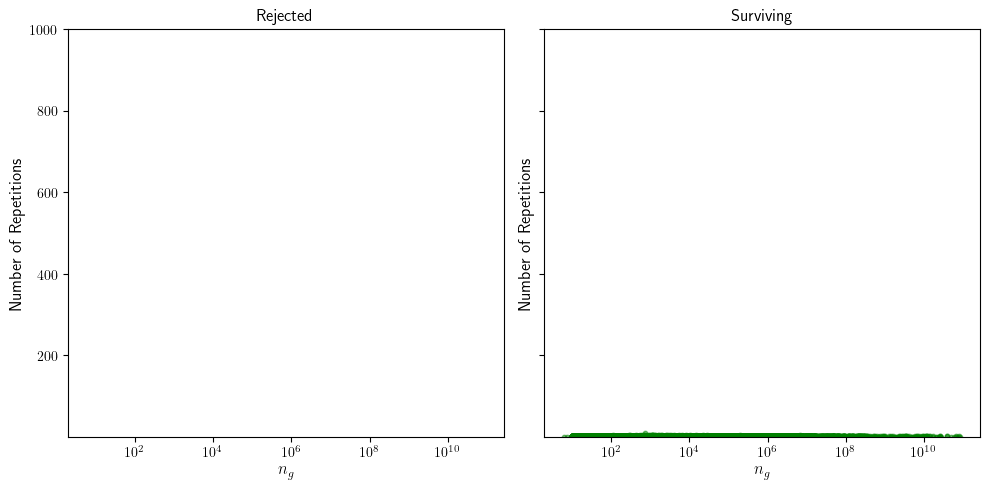

In [ ]:
from collections import Counter
import numpy as np

datas = [datawi0, datawa0]
for data in datas:

    fig, axd = plt.subplot_mosaic(
        [["Rejected", "Surviving"]],
        figsize=(10, 5),
        sharex=True,
        sharey=True,
    )

    for tindex, time in enumerate(data["t"]):

        mask = data["m"][tindex]
        densities = data["n"][tindex]
        fields    = data["B"][tindex]
        vectors   = data["rs"][tindex]

        for line in range(0, densities.shape[1], 1):

            mask_rej = mask[line]

            dens = densities[:, line]
            indexes = np.where(dens > 100)
            first, last = indexes[0][0], indexes[0][-1]
            dens = densities[first:last, line]

            counts = Counter(dens)
            items = counts.most_common()
            values, frequencies = zip(*items)

            if mask_rej == True:
                axd["Surviving"].scatter(values, frequencies, color="g", alpha=0.5, s=10)
            else:
                axd["Rejected"].scatter(values, frequencies, color="r", alpha=0.5, s=10)

    for name, ax in axd.items():
        ax.set_ylim(1, 1.0e+3)
        #ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_xlabel(r"$n_g$", fontsize=12)
        ax.set_ylabel("Number of Repetitions", fontsize=12)
        ax.set_title(name)

    fig.tight_layout()
    plt.show()

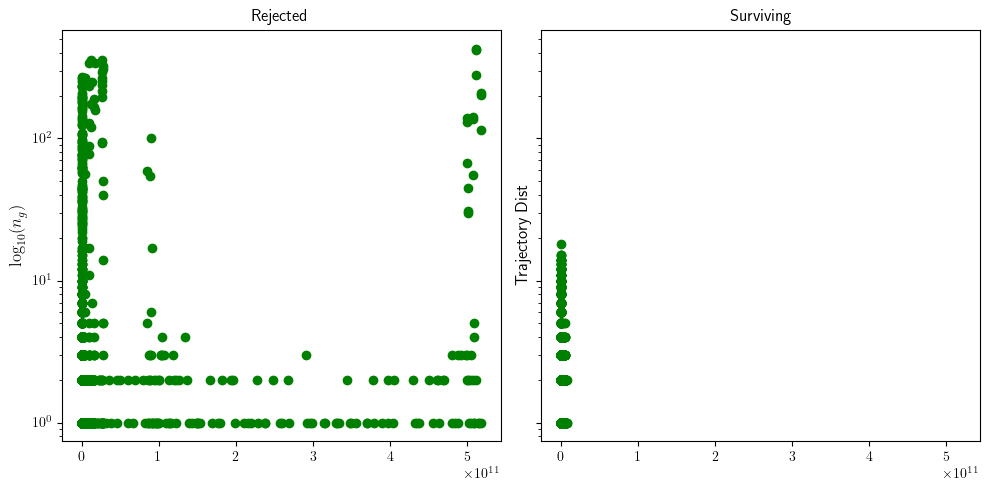

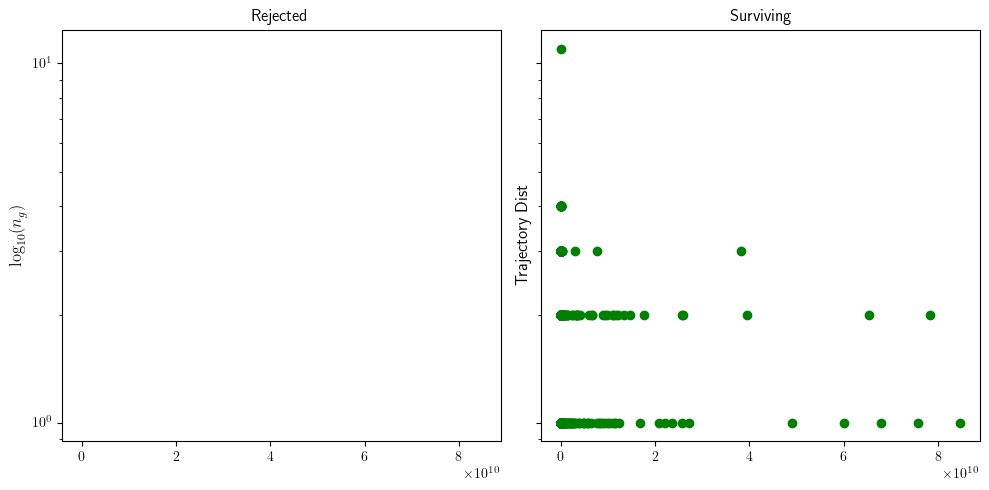

In [ ]:

from collections import Counter

datas = [datawi0, datawa0]
for data in datas:

    fig, axd = plt.subplot_mosaic(
        [["Rejected", "Surviving"]],
        figsize=(10, 5),
        sharex=True,
        sharey=True,
    )

    for tindex, time in enumerate(data["t"]):

        mask = data["m"][tindex]
        densities = data["n"][tindex]#[mask]
        fields    = data["B"][tindex]#[mask]
        vectors   = data["rs"][tindex]#[mask]

        for line in range(0, densities.shape[1], 1):

            mask_rej = mask[line]

            dens = densities[:, line]
            indexes = np.where(dens > 100) # where is the field line reaching the threshold of 100cm-3
            first, last = indexes[0][0], indexes[0][-1]
            field = fields[first:last, line]
            dens = densities[first:last, line] 
            vector = vectors[first:last, line, :] 
            segment_lengths = np.linalg.norm(np.diff(vector, axis=0), axis=1)
            distances = np.concatenate([np.zeros((1, )), np.cumsum(segment_lengths, axis=0)], axis=0)  # shape (1999)

            counts = Counter(dens)
            #print(counts.most_common(3))
            items = counts.most_common()
            values, frequencies = zip(*items)

            ax.bar(values, frequencies)
            ax.set_xlabel('Value')
            ax.set_ylabel('Number of Repetitions')
            ax.set_title('Frequency of Values (sorted)')
            
            if mask_rej == True:
                #axd["Surviving"].plot(distances, field, '-', color="g")
                axd["Surviving"].scatter(values, frequencies, color="g")
                #axd["Surviving"].tick_params(axis='x', rotation=45)
            else:    
                axd["Rejected"].scatter(values, frequencies, color="g")            
                #axd["Rejected"].tick_params(axis='x', rotation=45)

    for name, ax in axd.items():
        ax.set_yscale("log")
        #ax.set_xscale("log")
        ax.set_ylabel(r"Trajectory Dist", fontsize=12)
        ax.set_title(name)

    axd["Rejected"].set_ylabel(r"$\log_{10}(n_g)$", fontsize=12)

    fig.tight_layout()
    plt.show()


# Distance Traveled on Average, at least and most

4.5515625
4.55206298828125


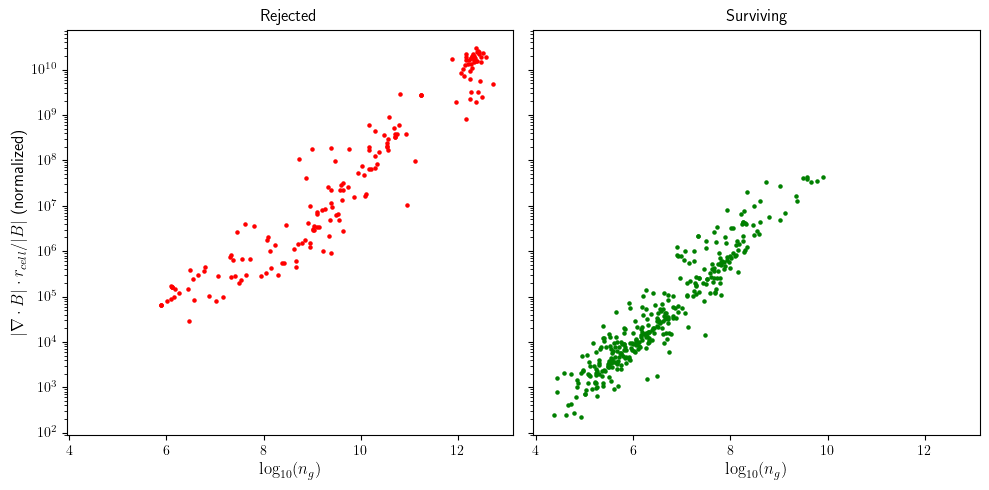

2.725
2.95
3.45
3.7
3.95
4.2
4.28671875
4.29013671875
4.290350341796875
4.2903991699218755
4.29041748046875
4.290425872802735
4.290433120727539
4.290436935424805
4.2904407501220705
4.290444564819336
4.290448379516602
4.290452194213867
4.290456008911133
4.290459823608399
4.290463638305664
4.29046745300293
4.2904712677001955
4.290475082397461
4.290478897094727
4.290482711791992
4.290486526489258
4.290490341186524
4.290492248535156


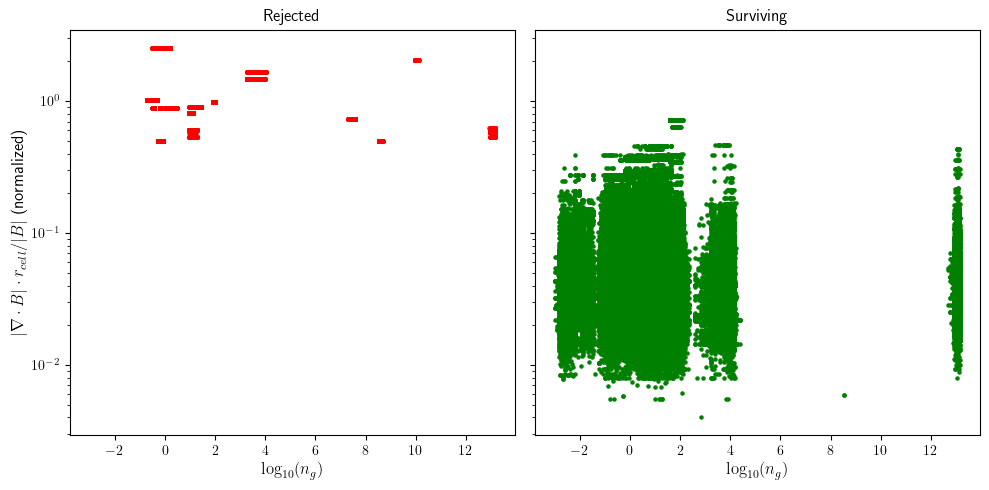

In [ ]:
datas = [data_2i0_dense, data_2a0_dense]
for data in datas:

    fig, axd = plt.subplot_mosaic(
        [["Rejected", "Surviving"]],
        figsize=(10, 5),
        sharex=True,
        sharey=True,
    )
    total = 0
    for tindex, time in enumerate(data["t"]):
        print(time)
        mask = data["m"][tindex]

        densities = data["ndivn"][tindex]
        NormDivB = data["ndivb"][tindex]

        surv_densities = np.log10(densities[mask])
        rej_densities = np.log10(densities[np.logical_not(mask)])
        #print(surv_densities.shape)
        total += surv_densities.shape[0]
        surv_div = abs(NormDivB[mask])
        rej_div = abs(NormDivB[np.logical_not(mask)])

        axd["Rejected"].scatter(rej_densities, rej_div, s=5, color="r")
        axd["Surviving"].scatter(surv_densities, surv_div, s=5, color="g")

    for name, ax in axd.items():
        ax.set_yscale("log")
        ax.set_xlabel(r"$\log_{10}(n_g)$", fontsize=12)
        ax.set_title(name)

    axd["Rejected"].set_ylabel(r"$|\nabla \cdot B| \cdot r_{cell} / |B|$ (normalized)", fontsize=12)

    fig.tight_layout()
    plt.show()


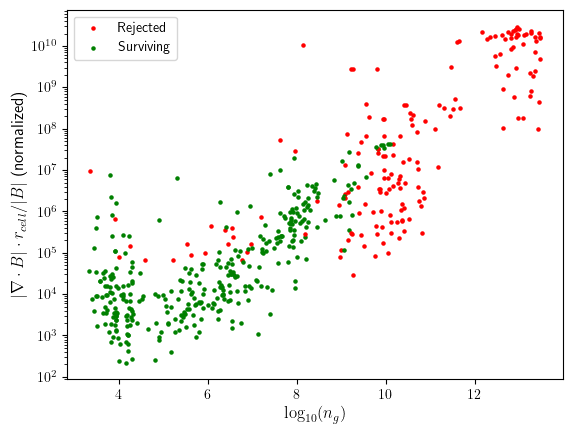

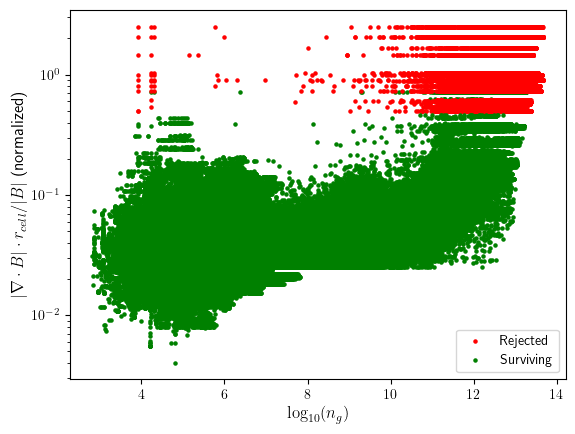

In [ ]:
#tindex = -1

datas = [data_2i0_dense, data_2a0_dense]
for data in datas:

    fig, ax = plt.subplots()

    for tindex, time in enumerate(data["t"]):
        #print(time, data.keys())
        mask = data["m"][tindex]

        densities = data["ndivn"][tindex]
        densities = data["ns"][tindex]
        #magnetic_fields = data["Bs"][tindex]
        NormDivB = data["ndivb"][tindex]

        surv_densities = np.log10(densities[mask])
        rej_densities = np.log10(densities[np.logical_not(mask)])

        surv_div = abs(NormDivB[mask])
        rej_div = abs(NormDivB[np.logical_not(mask)])

        ax.scatter(rej_densities, rej_div, s=5, color="r", label="Rejected" if tindex == 0 else None)
        ax.scatter(surv_densities, surv_div, s=5, color="g", label="Surviving" if tindex == 0 else None)

    ax.set_yscale("log")
    ax.set_xlabel(r"$\log_{10}(n_g)$", fontsize= 12)
    ax.set_ylabel(r"$|\nabla \cdot B| \cdot r_{cell} / |B|$ (normalized)",fontsize= 12)
    ax.legend()
    plt.show()